<a href="https://colab.research.google.com/github/efrat-dev/insider-threat-detector/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries and Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gdown
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data Loading


In [5]:
file_id = "1cpS2EDfkiYhMZ4NiMhUtFNZas4nM-Rjp"
url = f"https://drive.google.com/uc?id={file_id}"
output = "insider_threat_dataset.csv"
gdown.download(url, output, quiet=False)
df = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=1cpS2EDfkiYhMZ4NiMhUtFNZas4nM-Rjp
To: /content/insider_threat_dataset.csv
100%|██████████| 56.4M/56.4M [00:00<00:00, 73.3MB/s]


# Basic Overview

## Dataset Structure & Types

In [6]:
df = pd.read_csv('/content/drive/My Drive/insider_threat_dataset1.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of unique employees: {df['employee_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days in dataset: {(pd.to_datetime(df['date'].max()) - pd.to_datetime(df['date'].min())).days}")
print(f"Malicious employees: {df['is_emp_malicious'].sum()} ({df['is_emp_malicious'].mean()*100:.2f}%)")
print(f"Malicious days: {df['is_malicious'].sum()} ({df['is_malicious'].mean()*100:.2f}%)")

Dataset shape: (299880, 50)
Number of unique employees: 1666
Date range: 2025-02-02 to 2025-07-31
Total days in dataset: 179
Malicious employees: 14940 (4.98%)
Malicious days: 7521 (2.51%)


In [5]:
df.head(10)

,employee_id,date,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,is_malicious,risk_travel_indicator,num_print_commands,total_printed_pages,num_print_commands_off_hours,num_printed_pages_off_hours,num_color_prints,num_bw_prints,ratio_color_prints,printed_from_other,print_campuses,num_burn_requests,max_request_classification,avg_request_classification,num_burn_requests_off_hours,total_burn_volume_mb,total_files_burned,burned_from_other,burn_campuses,is_abroad,trip_day_number,country_name,is_hostile_country_trip,hostility_country_level,is_official_trip,num_entries,num_exits,first_entry_time,last_exit_time,total_presence_minutes,entered_during_night_hours,num_unique_campus,early_entry_flag,late_exit_flag,entry_during_weekend,row_modified,modification_details,is_emp_malicious
0,1,2025-02-02,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,3,0,0.00,1,119,4,0,0,0,NaN,NaN,0,0,0,1,1,08:50,16:14,443,0,1,0,0,1,True,num_burn_requests += 3; total_files_burned += ...,0
1,1,2025-02-03,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,1,1,06:28,21:24,892,0,1,1,0,0,True,first_entry_time shifted by -3 mins; updated n...,0
2,1,2025-02-04,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,2,0,0.36,0,280,2,0,0,0,NaN,NaN,0,0,0,1,1,06:26,20:14,827,0,1,0,0,0,True,num_burn_requests += 2; total_files_burned += ...,0
3,1,2025-02-05,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,1,1,08:34,17:00,496,0,1,0,0,0,True,first_entry_time shifted by -10 mins; updated ...,0
4,1,2025-02-06,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,2,1,0,0,0,1,0.00,0,1,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,1,1,09:51,20:47,656,0,1,0,0,0,False,NaN,0
5,1,2025-02-07,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,False,NaN,0
6,1,2025-02-08,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,2,1,0,0,0,1,0.18,0,1,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,False,NaN,0
7,1,2025-02-09,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,False,NaN,0
8,1,2025-02-10,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.00,0,0,0,0,0,0,NaN,NaN,0,0,0,2,2,09:46,21:33,703,0,1,0,0,0,True,first_entry_time shifted by -4 mins; updated n...,0
9,1,2025-02-11,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0,0,0,0.00,0,0,1,0,0.08,0,186,9,0,0,0,NaN,NaN,0,0,0,1,1,07:50,18:06,616,0,1,0,0,0,True,num_burn_requests += 1; total_files_burned += ...,0


In [7]:
df.shape

(299880, 50)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299880 entries, 0 to 299879
Data columns (total 50 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   employee_id                   299880 non-null  int64  
 1   date                          299880 non-null  object 
 2   employee_department           299880 non-null  object 
 3   employee_campus               299880 non-null  object 
 4   employee_position             299880 non-null  object 
 5   employee_seniority_years      299880 non-null  int64  
 6   is_contractor                 299880 non-null  int64  
 7   employee_classification       299880 non-null  int64  
 8   has_foreign_citizenship       299880 non-null  int64  
 9   has_criminal_record           299880 non-null  int64  
 10  has_medical_history           299880 non-null  int64  
 11  employee_origin_country       299880 non-null  object 
 12  is_malicious                  299880 non-nul

**299K employee security records** - Most data is complete, but only 2% travel internationally. Focus analysis on travel subset since it includes hostile country flags.

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['first_entry_time'] = pd.to_datetime(df['first_entry_time'], errors='coerce')
df['last_exit_time'] = pd.to_datetime(df['last_exit_time'], errors='coerce')

## Column Classification

### Type Classification

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

binary_cols = [
    col for col in numerical_cols
    if df[col].dropna().isin([0, 1]).all()
]

categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols_no_binary = [col for col in numerical_cols if col not in binary_cols]

datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns

In [11]:
print(categorical_cols)

Index(['employee_department', 'employee_campus', 'employee_position',
       'employee_origin_country', 'country_name', 'modification_details'],
      dtype='object')


In [12]:
print(binary_cols)

['is_contractor', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'is_malicious', 'risk_travel_indicator', 'printed_from_other', 'burned_from_other', 'is_abroad', 'is_hostile_country_trip', 'is_official_trip', 'entered_during_night_hours', 'early_entry_flag', 'late_exit_flag', 'entry_during_weekend', 'is_emp_malicious']


In [13]:
print(numerical_cols_no_binary)

['employee_id', 'employee_seniority_years', 'employee_classification', 'num_print_commands', 'total_printed_pages', 'num_print_commands_off_hours', 'num_printed_pages_off_hours', 'num_color_prints', 'num_bw_prints', 'ratio_color_prints', 'print_campuses', 'num_burn_requests', 'max_request_classification', 'avg_request_classification', 'num_burn_requests_off_hours', 'total_burn_volume_mb', 'total_files_burned', 'burn_campuses', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_exits', 'total_presence_minutes', 'num_unique_campus']


In [14]:
print(datetime_cols)

Index(['date', 'first_entry_time', 'last_exit_time'], dtype='object')


### Category Classification

#### Numeric

In [15]:
employee_characteristics = ['employee_seniority_years']
print_activity_cols = ['num_print_commands', 'total_printed_pages', 'num_print_commands_off_hours',
                      'num_printed_pages_off_hours', 'num_color_prints', 'num_bw_prints',
                      'ratio_color_prints', 'print_campuses']
burn_activity_cols = ['num_burn_requests', 'max_request_classification', 'avg_request_classification',
                     'num_burn_requests_off_hours', 'total_burn_volume_mb', 'total_files_burned',
                     'burn_campuses']
travel_cols = ['trip_day_number']
building_access_cols = ['num_entries', 'num_exits', 'total_presence_minutes',
                       'entered_during_night_hours', 'num_unique_campus']

#### Boolean

In [16]:
boolean_employee_characteristics = [
    'is_contractor', 'has_foreign_citizenship', 'has_criminal_record',
    'has_medical_history', 'is_malicious', 'is_emp_malicious'
]

boolean_media_activity_cols = [
    'printed_from_other', 'burned_from_other'
]

boolean_travel_cols = [
    'is_abroad', 'is_hostile_country_trip', 'is_official_trip', 'risk_travel_indicator'
]

boolean_building_access_cols = [
    'entered_during_night_hours', 'early_entry_flag', 'late_exit_flag', 'entry_during_weekend'
]

#### Categorical

In [17]:
categorical_employee_characteristics = [
    'employee_position', 'employee_department', 'employee_classification', 'employee_campus'
]

categorical_country_cols = [
    'country_origin_country', 'country_name'
]

#### Datetime

In [18]:
datetime_activity_cols = [
    'date', 'first_entry_time', 'last_exit_time'
]

Note: employee_id is not one of the columns here.

# Data Quality Check

In [94]:
print("\n=== MISSING VALUES ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])


=== MISSING VALUES ANALYSIS ===
                      Missing_Count  Missing_Percentage
trip_day_number              293771           97.962852
country_name                 293771           97.962852
modification_details         263861           87.988862
last_exit_time               129506           43.185941
first_entry_time             129506           43.185941


**Missing data pattern**: 43% missing entry/exit times suggests many employees work remotely or have flexible access - could be important for anomaly detection.

# Target Variable Analysis
Purpose: Analyze the distribution of the target variable (is_malicious) and
understand the class imbalance. This is crucial for understanding the
baseline performance and choosing appropriate modeling strategies.

In [22]:
def analyze_target_distribution(df, target_column, positive_label='Positive', negative_label='Negative', title_suffix=''):
    """
    Generic function to analyze and visualize binary target variable distribution

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    target_column : str
        Name of the target column to analyze
    positive_label : str
        Label for positive class (value = 1)
    negative_label : str
        Label for negative class (value = 0)
    title_suffix : str
        Additional text to add to plot titles
    """

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Get value counts
    target_counts = df[target_column].value_counts()

    # Absolute counts bar plot
    axes[0].bar(target_counts.index, target_counts.values)
    axes[0].set_title(f'Distribution of {positive_label} vs {negative_label}{title_suffix}')
    axes[0].set_xlabel(target_column.replace('_', ' ').title())
    axes[0].set_ylabel('Count')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels([negative_label, positive_label])

    # Add value labels on bars
    for i, v in enumerate(target_counts.values):
        axes[0].text(i, v + 0.01*max(target_counts.values), str(v), ha='center')

    # Percentage distribution pie chart
    target_pct = df[target_column].value_counts(normalize=True) * 100
    axes[1].pie(target_pct.values, labels=[negative_label, positive_label], autopct='%1.2f%%')
    axes[1].set_title(f'Percentage Distribution{title_suffix}')

    plt.tight_layout()
    plt.show()

    # Calculate and print class imbalance ratio
    imbalance_ratio = target_counts[0] / target_counts[1] if target_counts[1] > 0 else float('inf')
    print(f"\nClass Imbalance Ratio ({negative_label}:{positive_label}): {imbalance_ratio:.2f}:1")
    print(f"Total samples: {len(df)}")
    print(f"{negative_label}: {target_counts[0]} ({target_pct[0]:.2f}%)")
    print(f"{positive_label}: {target_counts[1]} ({target_pct[1]:.2f}%)")

## is_malicious

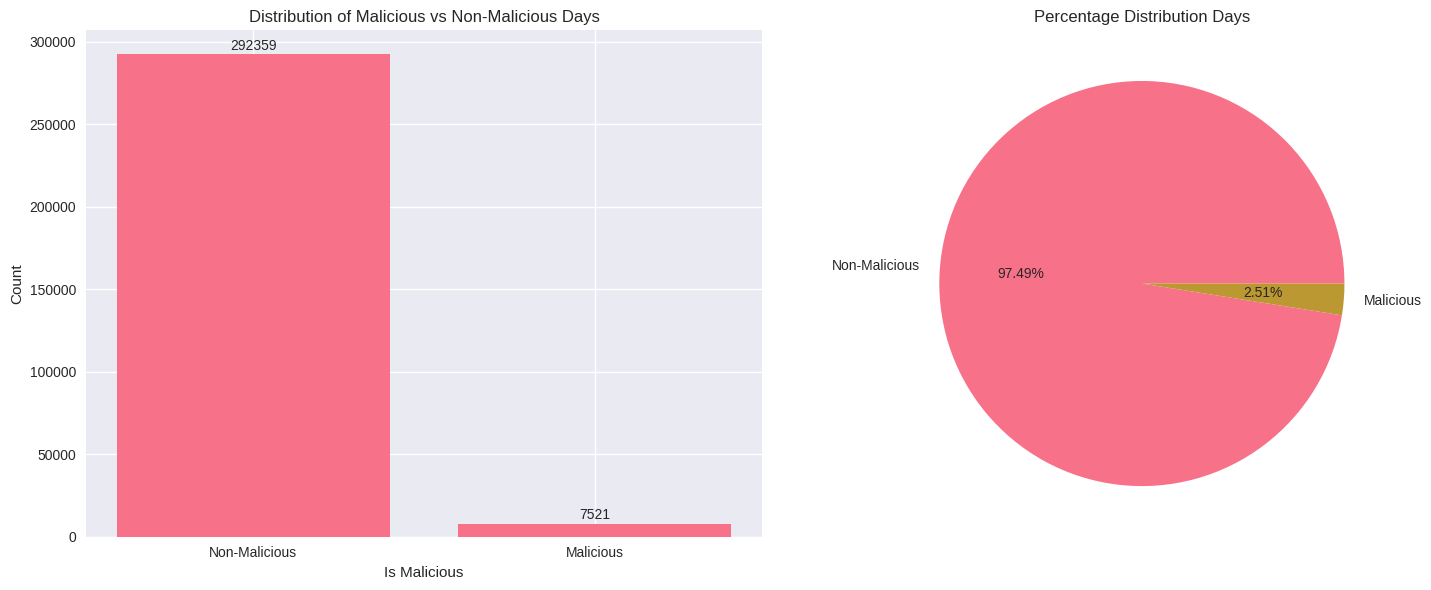


Class Imbalance Ratio (Non-Malicious:Malicious): 38.87:1
Total samples: 299880
Non-Malicious: 292359 (97.49%)
Malicious: 7521 (2.51%)


In [24]:
analyze_target_distribution(
    df,
    'is_malicious',
    positive_label='Malicious',
    negative_label='Non-Malicious',
    title_suffix=' Days'
)

**Severe class imbalance**: Only 2.5% malicious cases (39:1 ratio) - will need sampling techniques or specialized metrics for model training.

## is_emp_malicious

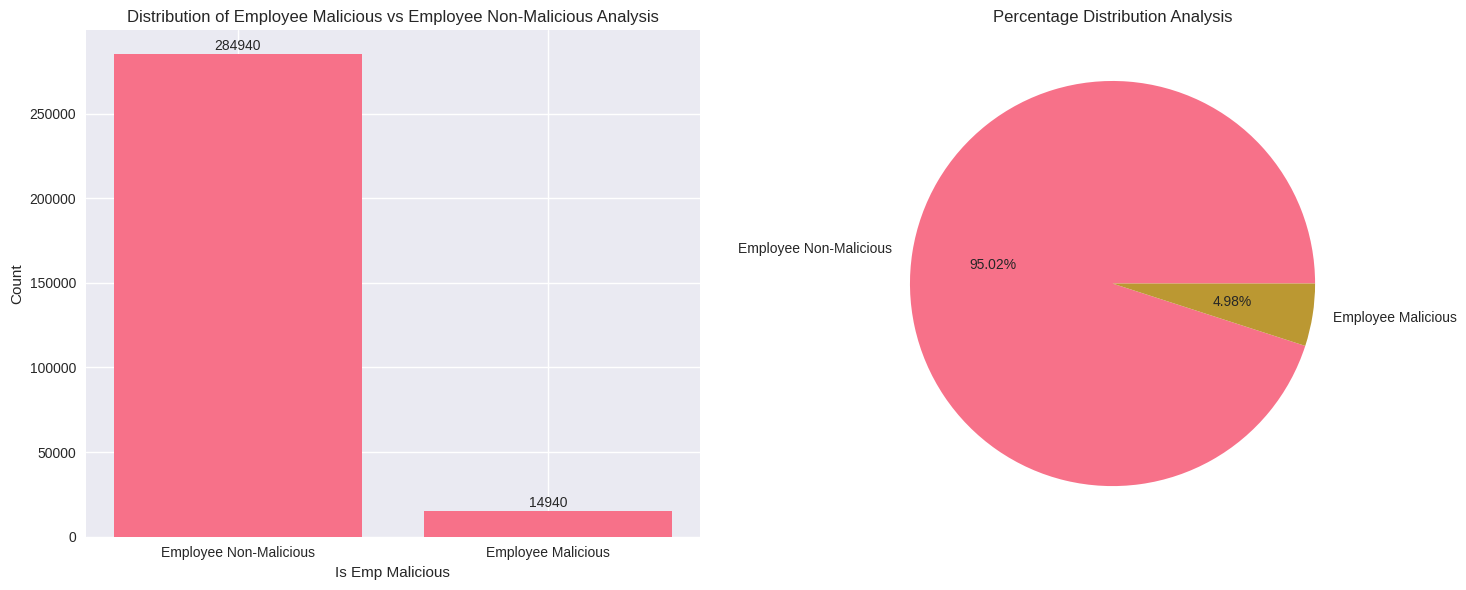


Class Imbalance Ratio (Employee Non-Malicious:Employee Malicious): 19.07:1
Total samples: 299880
Employee Non-Malicious: 284940 (95.02%)
Employee Malicious: 14940 (4.98%)


In [26]:
analyze_target_distribution(
    df,
    'is_emp_malicious',
    positive_label='Employee Malicious',
    negative_label='Employee Non-Malicious',
    title_suffix=' Analysis'
)

**Key insight**: 5% of employees are flagged as malicious, but they generate only 2.5% of total incidents - indicating most malicious employees have single violations rather than repeat offenses.

# Numerical Columns Analysis

In [27]:
def filter_valid_cols(cols):
    """
    Returns only columns that are numerical (but not boolean/binary).

    Args:
        cols (list): List of column names to check

    Returns:
        list: Only the numerical non-binary columns from the input
    """
    return [col for col in cols if col in numerical_cols_no_binary]

## Employee Characteristics

In [28]:
print(df[filter_valid_cols(employee_characteristics)].describe())

       employee_seniority_years
count             299880.000000
mean                  12.542017
std                    7.343234
min                    0.000000
25%                    7.000000
50%                   12.000000
75%                   18.000000
max                   31.000000


**Mature workforce**: Average 12.5 years experience with stable distribution (0-31 years range). Most employees have 7-18 years seniority - suggests low turnover in security-sensitive organization.

## Print Activity

In [29]:
print(df[filter_valid_cols(print_activity_cols)].describe())

       num_print_commands  total_printed_pages  num_print_commands_off_hours  \
count       299880.000000        299880.000000                 299880.000000   
mean             1.623816             6.217810                      0.036301   
std              2.622662            17.302238                      0.241232   
min              0.000000             0.000000                      0.000000   
25%              0.000000             0.000000                      0.000000   
50%              0.000000             0.000000                      0.000000   
75%              3.000000             5.000000                      0.000000   
max             17.000000           728.000000                      8.000000   

       num_printed_pages_off_hours  num_color_prints  num_bw_prints  \
count                299880.000000     299880.000000  299880.000000   
mean                      0.232516          1.693531       4.445145   
std                       2.715902          6.501857      12.06742

**Low printing activity**: Most employees (50%) don't print at all. Those who do print average 6 pages with minimal off-hours activity (0.04% of commands). Heavy printers are rare but extreme outliers (max 728 pages) - potential data exfiltration risk indicators.

## Burn Activity

In [30]:
print(df[filter_valid_cols(burn_activity_cols)].describe())

       num_burn_requests  max_request_classification  \
count      299880.000000               299880.000000   
mean            0.417644                    0.144311   
std             1.308474                    0.503758   
min             0.000000                    0.000000   
25%             0.000000                    0.000000   
50%             0.000000                    0.000000   
75%             0.000000                    0.000000   
max            24.000000                    4.000000   

       avg_request_classification  num_burn_requests_off_hours  \
count               299880.000000                299880.000000   
mean                     0.128692                     0.027271   
std                      0.417181                     0.275246   
min                      0.000000                     0.000000   
25%                      0.000000                     0.000000   
50%                      0.000000                     0.000000   
75%                      0.000000

**Rare but high-risk activity**: 75% of employees never burn data to external media. However, when it occurs, volumes are significant (average 166MB, max 183GB) with classification levels up to 4 - critical security monitoring point for data exfiltration.

## Travel

In [31]:
print(df[filter_valid_cols(travel_cols)].describe())

       trip_day_number
count      6109.000000
mean          5.102799
std           3.287557
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          14.000000


**Short business trips dominate**: Among the 2% who travel internationally, trips are typically brief (median 4 days, average 5 days, max 14 days) - suggests controlled, mission-specific travel rather than extended assignments.

## Building Access

In [32]:
print(df[filter_valid_cols(building_access_cols)].describe())

         num_entries      num_exits  total_presence_minutes  num_unique_campus
count  299880.000000  299880.000000           299880.000000      299880.000000
mean        0.692007       0.692007              310.634064           0.575637
std         0.687550       0.687550              285.686630           0.514200
min         0.000000       0.000000                0.000000           0.000000
25%         0.000000       0.000000                0.000000           0.000000
50%         1.000000       1.000000              430.000000           1.000000
75%         1.000000       1.000000              543.000000           1.000000
max         4.000000       4.000000             1017.000000           3.000000


**Standard work patterns**: Most employees have single daily entry/exit (median 1) spending ~5 hours on-site (310 min average). 25% have no physical access records - confirming significant remote work population in this organization.

## Correlation Analysis

=== CORRELATION ANALYSIS - ALL FEATURES ===
Total numerical columns: 39


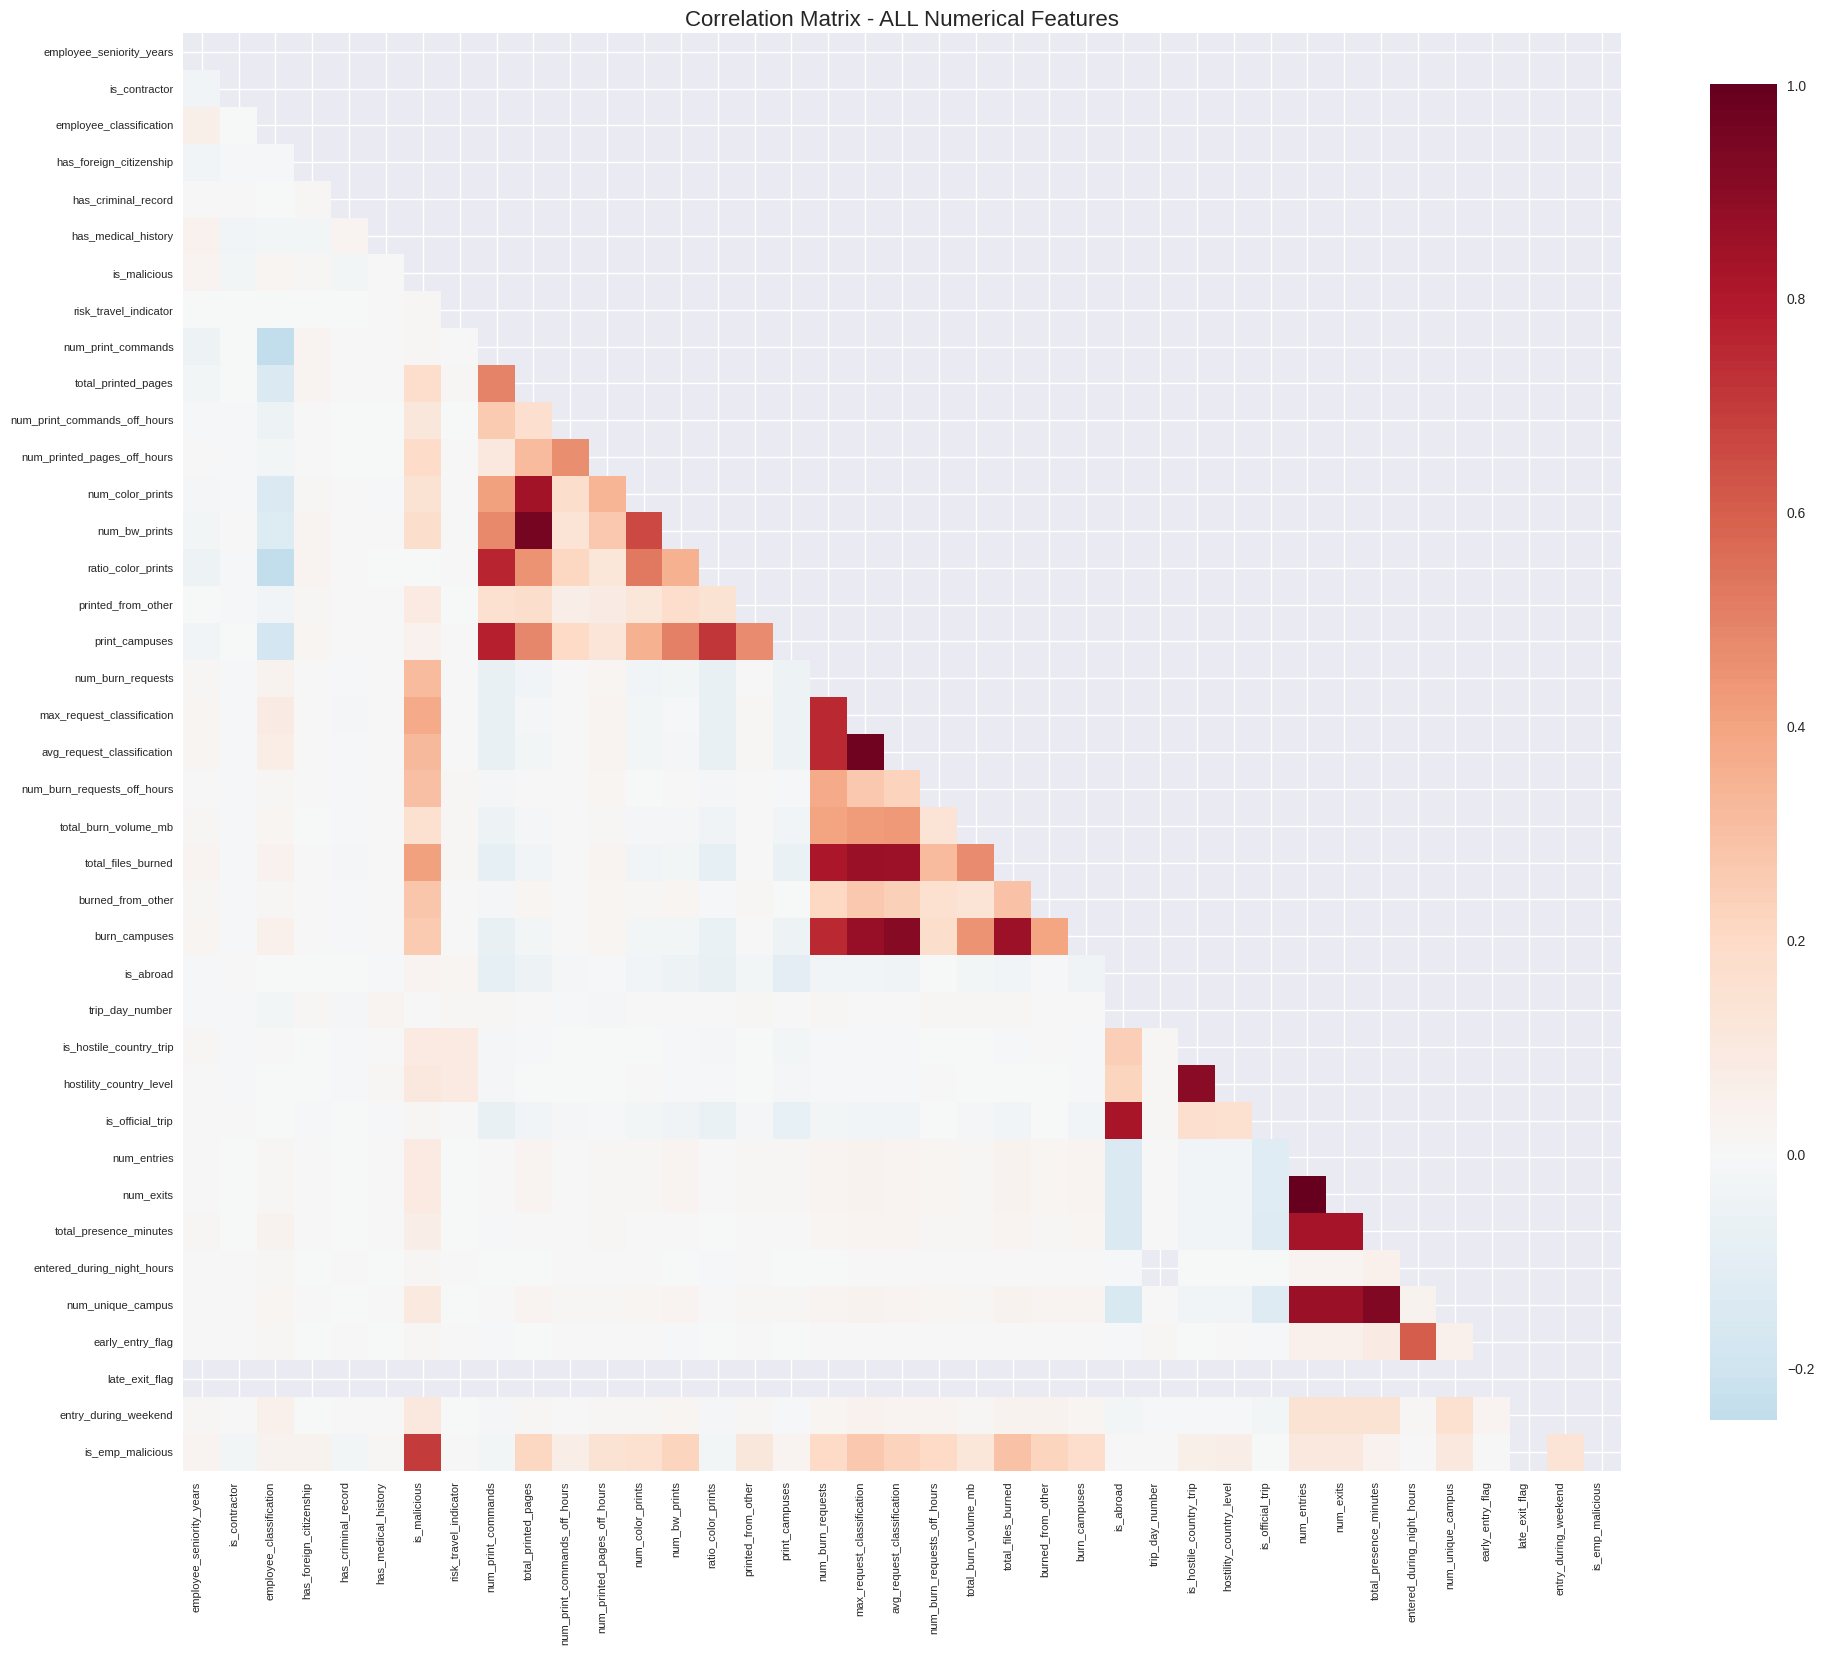

"\nHOW TO USE - Call each function separately to see immediate results:\n\n# Step 1: Analyze all correlations\n\n# Step 2: Find top correlations with target\ntop_features = find_top_correlations_with_target(full_matrix, 'is_malicious', top_n=15)\n\n# Step 3: Show clean correlation matrix for top features\ntop_matrix = show_top_feature_correlations(df, top_features, 'is_malicious')\n\n# Step 4: Find interesting feature pairs\ninteresting_pairs = find_interesting_feature_pairs(top_matrix, 'is_malicious')\n\n# Step 5: Show complete summary\nresults = {\n    'full_correlation_matrix': full_matrix,\n    'top_correlation_matrix': top_matrix,\n    'all_features': all_features,\n    'top_features': top_features,\n    'interesting_pairs': interesting_pairs\n}\nrun_complete_analysis_summary(df, results)\n"

In [88]:
def analyze_all_correlations(df, target_col='is_malicious'):
    """
    Analyze correlations for all numerical features in the dataset.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataset
    target_col : str
        Target variable column name

    Returns:
    --------
    tuple: (correlation_matrix, numerical_columns_list)
        Full correlation matrix and list of numerical columns analyzed
    """
    print("=== CORRELATION ANALYSIS - ALL FEATURES ===")

    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove ID columns that shouldn't be in correlation analysis
    id_cols = ['employee_id']
    numerical_cols = [col for col in numerical_cols if col not in id_cols]

    print(f"Total numerical columns: {len(numerical_cols)}")

    # Calculate correlation matrix
    correlation_matrix = df[numerical_cols].corr()

    plt.figure(figsize=(20, 18))

    # Upper triangle mask for cleaner visualization
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix,
               mask=mask,
               annot=False,
               cmap='RdBu_r',
               center=0,
               square=True,
               cbar_kws={"shrink": .8})

    plt.title('Correlation Matrix - ALL Numerical Features', fontsize=16)
    plt.xticks(rotation=90, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    return correlation_matrix, numerical_cols

full_matrix, all_features = analyze_all_correlations(df, target_col='is_malicious')

**High Multicollinearity**
- Multiple variable pairs show correlations > 0.8
- Feature redundancy evident from block patterns

**Variable Clustering**
- Time-related variables cluster together
- Performance metrics are highly intercorrelated

**Statistical Risk**
- Potential overfitting due to correlated predictors
- Feature selection critical for stable models


=== TOP 15 CORRELATIONS WITH IS_MALICIOUS ===
Top features by correlation with target:
   1. is_emp_malicious: 0.6927
   2. total_files_burned: 0.4140
   3. max_request_classification: 0.3787
   4. avg_request_classification: 0.3247
   5. num_burn_requests: 0.3138
   6. num_burn_requests_off_hours: 0.2981
   7. burned_from_other: 0.2822
   8. burn_campuses: 0.2613
   9. num_printed_pages_off_hours: 0.1933
  10. total_printed_pages: 0.1807
  11. num_bw_prints: 0.1750
  12. total_burn_volume_mb: 0.1645
  13. num_color_prints: 0.1481
  14. num_print_commands_off_hours: 0.1140
  15. hostility_country_level: 0.1059


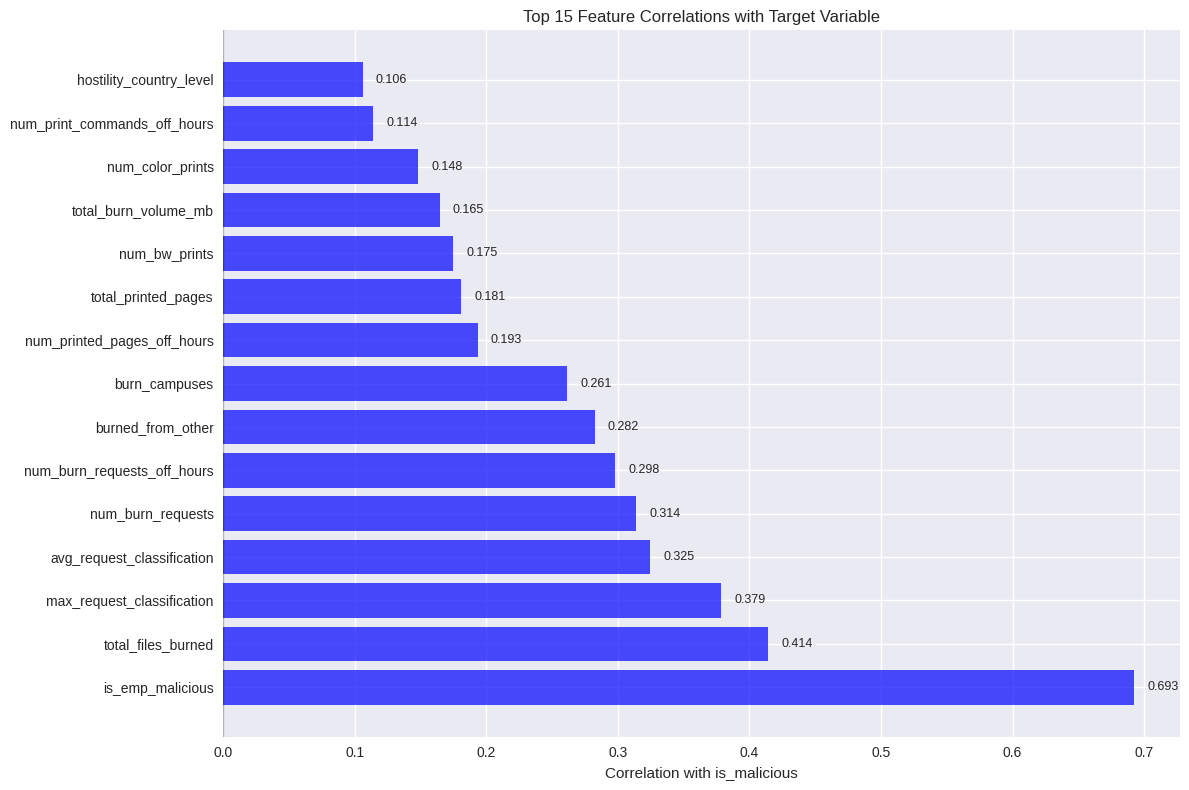

In [89]:
def find_top_correlations_with_target(correlation_matrix, target_col='is_malicious', top_n=20):
    """
    Identify features with highest correlations to the target variable.

    Parameters:
    -----------
    correlation_matrix : pandas.DataFrame
        Correlation matrix from analyze_all_correlations()
    target_col : str
        Target variable column name
    top_n : int
        Number of top correlations to return

    Returns:
    --------
    list: Feature names with highest absolute correlations to target
    """
    print(f"\n=== TOP {top_n} CORRELATIONS WITH {target_col.upper()} ===")

    if target_col not in correlation_matrix.columns:
        print(f"Target column '{target_col}' not found!")
        return []

    # Extract target correlations
    target_correlations = correlation_matrix[target_col].drop(target_col, errors='ignore')

    # Sort by absolute correlation value
    target_correlations_sorted = target_correlations.reindex(
        target_correlations.abs().sort_values(ascending=False).index
    )

    # Get top N features
    top_features = target_correlations_sorted.head(top_n)

    print("Top features by correlation with target:")
    for i, (feature, corr_val) in enumerate(top_features.items(), 1):
        if not pd.isna(corr_val):
            print(f"  {i:2d}. {feature}: {corr_val:.4f}")

    # Visualization
    plt.figure(figsize=(12, max(8, top_n * 0.4)))
    colors = ['red' if x < 0 else 'blue' for x in top_features.values]
    bars = plt.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)

    plt.yticks(range(len(top_features)), top_features.index, fontsize=10)
    plt.xlabel(f'Correlation with {target_col}')
    plt.title(f'Top {top_n} Feature Correlations with Target Variable')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

    # Add correlation values on bars
    for i, (bar, val) in enumerate(zip(bars, top_features.values)):
        plt.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.show()

    return top_features.index.tolist()


top_features = find_top_correlations_with_target(full_matrix, 'is_malicious', top_n=15)

The strongest predictor of malicious activity is the `is_emp_malicious` flag (0.69 correlation), followed by file burning behaviors and request classifications. Off-hours activity patterns emerge as consistent risk indicators across multiple variables, suggesting timing-based anomalies are critical detection signals. The data reveals clear behavioral signatures of malicious users, with file burning operations and abnormal work schedules being key markers. Geographic hostility shows minimal predictive value (0.11), indicating that behavioral patterns matter significantly more than location-based factors for identifying insider threats.


=== CORRELATION MATRIX - TOP 15 FEATURES ===


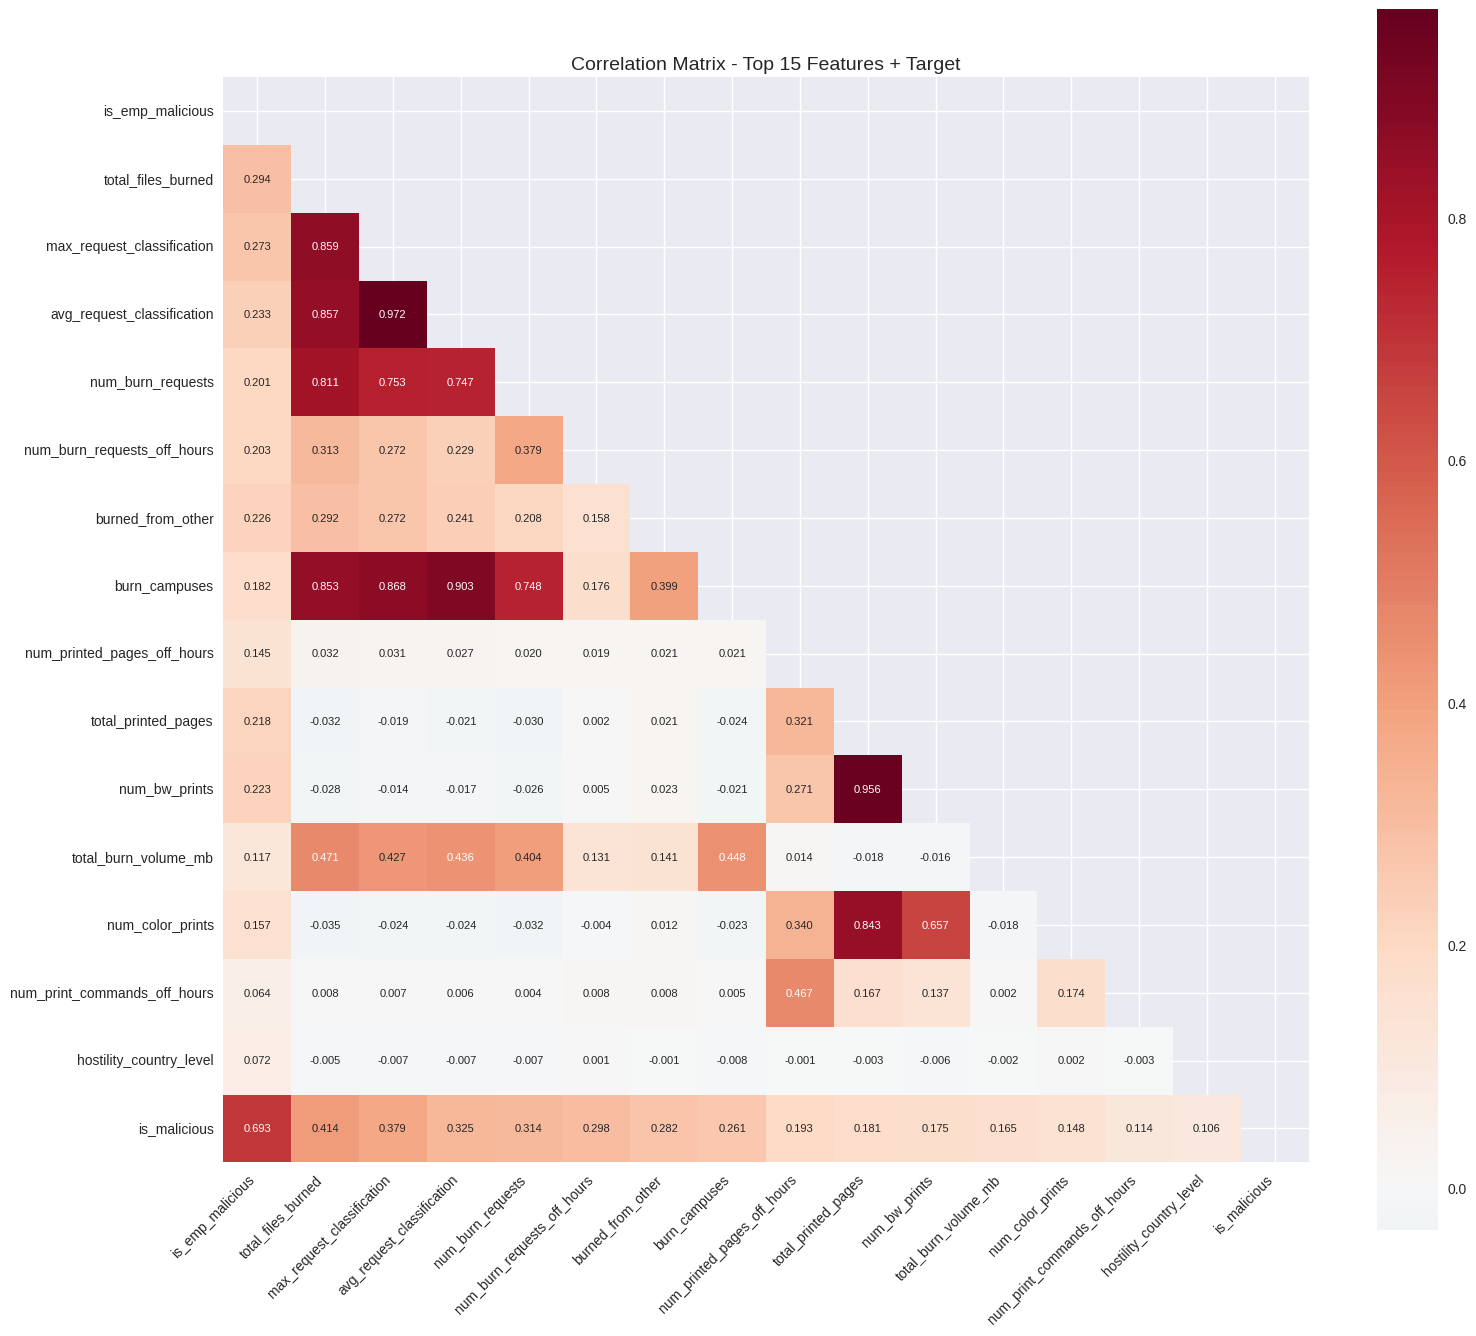

In [90]:
def show_top_feature_correlations(df, top_features, target_col='is_malicious'):
    """
    Display correlation matrix for top features only (cleaner visualization).

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataset
    top_features : list
        List of top feature names from find_top_correlations_with_target()
    target_col : str
        Target variable column name

    Returns:
    --------
    pandas.DataFrame: Correlation matrix for top features + target
    """
    print(f"\n=== CORRELATION MATRIX - TOP {len(top_features)} FEATURES ===")

    analysis_features = top_features.copy()
    if target_col in df.columns and target_col not in analysis_features:
        analysis_features.append(target_col)

    top_correlation_matrix = df[analysis_features].corr()
    plt.figure(figsize=(max(10, len(analysis_features)), max(8, len(analysis_features))))
    mask = np.triu(np.ones_like(top_correlation_matrix, dtype=bool))

    sns.heatmap(top_correlation_matrix,
               mask=mask,
               annot=True,
               cmap='RdBu_r',
               center=0,
               fmt='.3f',
               square=True,
               cbar_kws={"shrink": .8},
               annot_kws={'size': max(8, min(12, 80//len(analysis_features)))})

    plt.title(f'Correlation Matrix - Top {len(top_features)} Features + Target', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return top_correlation_matrix

top_matrix = show_top_feature_correlations(df, top_features, 'is_malicious')

**Key insights:** The correlation matrix reveals strong clustering among file burning variables (0.75-0.97 correlations), indicating high multicollinearity that requires feature selection. Request classification metrics show perfect correlation (0.97), suggesting one should be dropped to avoid redundancy. The strongest predictor remains `is_emp_malicious` (0.69), followed by file burning behaviors as the primary behavioral signature. Print-related activities show moderate intercorrelations but weaker relationships with the target, making them secondary indicators. Geographic hostility remains the weakest predictor, confirming behavioral patterns outweigh location-based risk factors.

In [91]:
def find_interesting_feature_pairs(correlation_matrix, exclude_target='is_malicious',
                                 min_correlation=0.3, top_n=15):
    """
    Discover highly correlated feature pairs (excluding target relationships).

    Parameters:
    -----------
    correlation_matrix : pandas.DataFrame
        Correlation matrix from show_top_feature_correlations()
    exclude_target : str
        Target column to exclude from pair analysis
    min_correlation : float
        Minimum absolute correlation threshold
    top_n : int
        Maximum number of pairs to display

    Returns:
    --------
    list: Tuples of (feature1, feature2, correlation_value)
    """
    print(f"\n=== TOP FEATURE-TO-FEATURE CORRELATIONS (|r| > {min_correlation}) ===")

    high_corr_pairs = []

    # Get non-target features
    features = [col for col in correlation_matrix.columns if col != exclude_target]

    # Find all feature pairs with high correlation
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            try:
                corr_val = correlation_matrix.loc[features[i], features[j]]
                if not pd.isna(corr_val) and abs(corr_val) >= min_correlation:
                    high_corr_pairs.append((features[i], features[j], corr_val))
            except:
                continue

    # Sort by absolute correlation strength
    high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

    if high_corr_pairs:
        print(f"Top feature pairs with high correlation:")
        for i, (feat1, feat2, corr_val) in enumerate(high_corr_pairs[:top_n]):
            print(f"  {i+1:2d}. {feat1} ↔ {feat2}: {corr_val:.3f}")
    else:
        print(f"No feature pairs found with correlation > {min_correlation}")

    return high_corr_pairs

interesting_pairs = find_interesting_feature_pairs(top_matrix, 'is_malicious')


=== TOP FEATURE-TO-FEATURE CORRELATIONS (|r| > 0.3) ===
Top feature pairs with high correlation:
   1. max_request_classification ↔ avg_request_classification: 0.972
   2. total_printed_pages ↔ num_bw_prints: 0.956
   3. avg_request_classification ↔ burn_campuses: 0.903
   4. max_request_classification ↔ burn_campuses: 0.868
   5. total_files_burned ↔ max_request_classification: 0.859
   6. total_files_burned ↔ avg_request_classification: 0.857
   7. total_files_burned ↔ burn_campuses: 0.853
   8. total_printed_pages ↔ num_color_prints: 0.843
   9. total_files_burned ↔ num_burn_requests: 0.811
  10. max_request_classification ↔ num_burn_requests: 0.753
  11. num_burn_requests ↔ burn_campuses: 0.748
  12. avg_request_classification ↔ num_burn_requests: 0.747
  13. num_bw_prints ↔ num_color_prints: 0.657
  14. total_files_burned ↔ total_burn_volume_mb: 0.471
  15. num_printed_pages_off_hours ↔ num_print_commands_off_hours: 0.467


**Feature Correlation Insights:**

**Severe Multicollinearity Issues:**
- Request classification metrics are nearly identical (r=0.97) - one must be dropped
- Print volume variables show extreme correlation (r=0.96) indicating redundancy
- File burning variables form a highly correlated cluster (r=0.75-0.85)

**Feature Groups Identified:**
- **Burning Behavior Cluster:** `total_files_burned`, `burn_campuses`, `num_burn_requests` (r>0.75)
- **Print Activity Cluster:** `total_printed_pages`, `num_bw_prints`, `num_color_prints` (r>0.65)
- **Request Risk Cluster:** `max_request_classification`, `avg_request_classification` (r=0.97)

**Modeling Implications:**
Feature selection is critical - the dataset contains 15 highly correlated pairs that will cause instability in linear models and inflate variance in predictions.

# Boolean Columns Analysis

In [33]:
def analyze_binary_cols(df, cols):
    """
    Analyzes binary columns and their relationship with 'is_malicious' target.

    Args:
        df (pandas.DataFrame): Input dataframe with 'is_malicious' column
        cols (list): List of binary column names to analyze

    Returns:
        pandas.DataFrame: Results with counts, percentages, and chi-square p-values
    """
    rows = []

    for col in cols:
        counts = df[col].value_counts()
        percent_ones = df[col].mean() * 100

        percent_mal_1 = df[df[col] == 1]['is_malicious'].mean() * 100 if counts.get(1, 0) > 0 else 0
        percent_mal_0 = df[df[col] == 0]['is_malicious'].mean() * 100 if counts.get(0, 0) > 0 else 0

        contingency = pd.crosstab(df[col], df['is_malicious'])
        if contingency.shape == (2, 2):
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            significant = 'Yes' if p_value < 0.05 else 'No'
        else:
            p_value = None
            significant = 'N/A'

        rows.append({
            'Column': col,
            'Count 0': counts.get(0, 0),
            'Count 1': counts.get(1, 0),
            '% of 1s': f"{percent_ones:.2f}%",
            '% malicious (0)': f"{percent_mal_0:.2f}%",
            '% malicious (1)': f"{percent_mal_1:.2f}%",
            'p-value': f"{p_value:.4f}" if p_value is not None else 'N/A',
            'Significant': significant
        })

    return pd.DataFrame(rows)

## Employee Characteristics

In [34]:
result_employee = analyze_binary_cols(df, boolean_employee_characteristics)
print(result_employee)

                    Column  Count 0  Count 1 % of 1s % malicious (0)  \
0            is_contractor   257040    42840  14.29%           2.64%   
1  has_foreign_citizenship   252900    46980  15.67%           2.39%   
2      has_criminal_record   284760    15120   5.04%           2.60%   
3      has_medical_history   254520    45360  15.13%           2.47%   
4             is_malicious   292359     7521   2.51%           0.00%   
5         is_emp_malicious   284940    14940   4.98%           0.03%   

  % malicious (1) p-value Significant  
0           1.69%  0.0000         Yes  
1           3.13%  0.0000         Yes  
2           0.77%  0.0000         Yes  
3           2.70%  0.0046         Yes  
4         100.00%  0.0000         Yes  
5          49.81%  0.0000         Yes  


**Key insight**: Foreign citizenship shows highest malicious rate (3.13% vs 2.39% baseline) while criminal records show lowest (0.77%). All factors are statistically significant - suggests background screening effectiveness varies by risk type.

## Media Activity

In [35]:
result_media = analyze_binary_cols(df, boolean_media_activity_cols)
print(result_media)

               Column  Count 0  Count 1 % of 1s % malicious (0)  \
0  printed_from_other   293225     6655   2.22%           2.29%   
1   burned_from_other   299009      871   0.29%           2.27%   

  % malicious (1) p-value Significant  
0          12.31%  0.0000         Yes  
1          84.27%  0.0000         Yes  


**Critical security indicator**: Using external devices for printing (12% malicious rate) or burning data (84% malicious rate) are the strongest predictors of malicious behavior - external device usage should trigger immediate security review.

## Travel Activity

In [36]:
result_travel = analyze_binary_cols(df, boolean_travel_cols)
print(result_travel)

                    Column  Count 0  Count 1 % of 1s % malicious (0)  \
0                is_abroad   293771     6109   2.04%           2.43%   
1  is_hostile_country_trip   299508      372   0.12%           2.46%   
2         is_official_trip   295725     4155   1.39%           2.48%   
3    risk_travel_indicator   299877        3   0.00%           2.51%   

  % malicious (1) p-value Significant  
0           6.02%  0.0000         Yes  
1          43.55%  0.0000         Yes  
2           4.65%  0.0000         Yes  
3          66.67%  0.0000         Yes  


**Extreme risk indicators**: Hostile country travel (44% malicious rate) and high-risk travel flags (67% malicious rate) are among the strongest threat predictors. Even general international travel shows elevated risk (6% vs 2.4% baseline).

## Building Access

In [37]:
result_building = analyze_binary_cols(df, boolean_building_access_cols)
print(result_building)

                       Column  Count 0  Count 1 % of 1s % malicious (0)  \
0  entered_during_night_hours   299388      492   0.16%           2.50%   
1            early_entry_flag   298553     1327   0.44%           2.49%   
2              late_exit_flag   299880        0   0.00%           2.51%   
3        entry_during_weekend   290801     9079   3.03%           2.22%   

  % malicious (1) p-value Significant  
0           6.91%  0.0000         Yes  
1           6.86%  0.0000         Yes  
2           0.00%     N/A         N/A  
3          11.85%  0.0000         Yes  


**Off-hours access = high risk**: Weekend access shows highest malicious rate (12% vs 2.2% baseline), followed by night entries (7%) and early arrivals (7%). No late exits recorded - suggests strict departure protocols.

# Categorical Variables Analysis

Statistics

In [38]:
def get_basic_categorical_stats(col_name, df):
    """
    Gets basic statistics for a categorical variable.

    Args:
        col_name (str): Name of the categorical column to analyze
        df (pandas.DataFrame): Input dataframe

    Returns:
        pandas.Series: Value counts for the column
    """
    print(f"\n=== ANALYSIS OF {col_name.upper()} ===")

    value_counts = df[col_name].value_counts()
    print(f"Number of unique values: {len(value_counts)}")
    print(f"Top 10 values:\n{value_counts.head(10)}")

    return value_counts

def calculate_malicious_rate(col_name, df):
    """
    Calculates malicious rate by category.

    Args:
        col_name (str): Name of the categorical column
        df (pandas.DataFrame): Input dataframe with 'is_malicious' column

    Returns:
        pandas.DataFrame: Malicious rates sorted by rate (descending)
    """
    malicious_rate = df.groupby(col_name)['is_malicious'].agg(['count', 'sum', 'mean']).reset_index()
    malicious_rate.columns = [col_name, 'total_count', 'malicious_count', 'malicious_rate']
    malicious_rate = malicious_rate.sort_values('malicious_rate', ascending=False)

    print(f"\nMalicious day rate by {col_name}:")
    print(malicious_rate.head(10))

    return malicious_rate

Graphs

In [55]:
def create_pie_chart(col_name, df, max_categories=10):
    """
    Creates a pie chart with values and percentages for categorical data.

    Args:
        col_name (str): Name of the categorical column
        df (pandas.DataFrame): Input dataframe
        max_categories (int): Maximum categories to show (rest grouped as 'Others')

    Returns:
        pandas.Series: Value counts of the column
    """
    value_counts = df[col_name].value_counts()
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # Take top categories only
    top_categories = value_counts.head(max_categories)

    # Group remaining categories as 'Others' if needed
    if len(value_counts) > max_categories:
        others_count = value_counts.iloc[max_categories:].sum()
        top_categories = pd.concat([top_categories, pd.Series([others_count], index=['Others'])])

    # Create custom labels with category name, count, and percentage
    labels = []
    total = top_categories.sum()
    for category, count in top_categories.items():
        percentage = (count / total) * 100
        labels.append(f'{category}\n({count:,})\n{percentage:.1f}%')

    # Create pie chart
    colors = plt.cm.Set3(range(len(top_categories)))
    wedges, texts, autotexts = ax.pie(top_categories.values,
                                     labels=labels,
                                     colors=colors,
                                     autopct='',  # Using custom labels instead
                                     startangle=90,
                                     textprops={'fontsize': 9, 'ha': 'center'})

    ax.set_title(f'Distribution of {col_name}', fontsize=14, fontweight='bold')

    # Add legend for charts with many categories
    if len(top_categories) > 6:
        ax.legend(wedges, [f'{cat}: {count:,}' for cat, count in top_categories.items()],
                 title=col_name, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    plt.tight_layout()
    plt.show()
    return value_counts

def create_distribution_plot(ax, col_name, value_counts, max_categories=20):
    """
    Creates a bar plot showing distribution of categorical variable.

    Args:
        ax (matplotlib.axes): Axes object to plot on
        col_name (str): Name of the categorical column
        value_counts (pandas.Series): Value counts for the column
        max_categories (int): Maximum categories to display
    """
    top_categories = value_counts.head(max_categories)
    ax.bar(range(len(top_categories)), top_categories.values)
    ax.set_title(f'Distribution of {col_name}')
    ax.set_xlabel(col_name)
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(top_categories)))
    ax.set_xticklabels(top_categories.index, rotation=45, ha='right')

def create_malicious_rate_plot(ax, col_name, malicious_rate, max_categories=20):
    """
    Creates a bar plot showing malicious rate by category.

    Args:
        ax (matplotlib.axes): Axes object to plot on
        col_name (str): Name of the categorical column
        malicious_rate (pandas.DataFrame): Malicious rate data by category
        max_categories (int): Maximum categories to display
    """
    top_malicious_rate = malicious_rate.head(max_categories)
    ax.bar(range(len(top_malicious_rate)), top_malicious_rate['malicious_rate'])
    ax.set_title(f'Malicious Rate by {col_name}')
    ax.set_xlabel(col_name)
    ax.set_ylabel('Malicious Rate')
    ax.set_xticks(range(len(top_malicious_rate)))
    ax.set_xticklabels(top_malicious_rate[col_name], rotation=45, ha='right')

def create_all_visualizations(col_name, df, value_counts, malicious_rate, max_categories=20):
      """
    Creates comprehensive visualization suite: distribution plot, malicious rate plot, and pie chart.

    Args:
        col_name (str): Name of the categorical column
        df (pandas.DataFrame): Input dataframe
        value_counts (pandas.Series): Value counts for the column
        malicious_rate (pandas.DataFrame): Malicious rate data by category
        max_categories (int): Maximum categories to display
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    create_distribution_plot(axes[0], col_name, value_counts, max_categories)
    create_malicious_rate_plot(axes[1], col_name, malicious_rate, max_categories)
    plt.tight_layout()
    plt.show()

    create_pie_chart(col_name, df, max_categories)

In [56]:
def analyze_categorical_variable(col_name, df, max_categories=20):
    """
    Comprehensive analysis of categorical variable and its relationship to target variable.

    Performs complete categorical analysis pipeline:
    1. Basic statistics and value counts
    2. Malicious rate calculation by category
    3. Visualization (bar plots + pie chart)
    4. Chi-square independence test

    Args:
        col_name (str): Name of the categorical column to analyze
        df (pandas.DataFrame): Input dataframe with 'is_malicious' column
        max_categories (int): Maximum categories to display in visualizations

    Returns:
        pandas.DataFrame: Malicious rate data by category (sorted by rate)
    """
    value_counts = get_basic_categorical_stats(col_name, df)
    malicious_rate = calculate_malicious_rate(col_name, df)
    create_all_visualizations(col_name, df, value_counts, malicious_rate, max_categories)

    return malicious_rate

## Employee Department Analysis

In [47]:
value_counts = get_basic_categorical_stats('employee_department', df)


=== ANALYSIS OF EMPLOYEE_DEPARTMENT ===
Number of unique values: 11
Top 10 values:
employee_department
R&D Department                        75600
Engineering Department                56520
Operations and Manufacturing          45720
Information Technology                38700
Project Management                    24660
Marketing and Business Development    23940
Finance                               12600
Human Resources                       10980
Security and Information Security      8100
Legal and Regulation                   2160
Name: count, dtype: int64


**Tech-heavy organization**: R&D (25%) and Engineering (19%) dominate workforce, with Operations (15%) and IT (13%) as next largest. Small Legal department (0.7%) suggests specialized/regulated industry requiring extensive security monitoring.

In [48]:
malicious_rate = calculate_malicious_rate('employee_department', df)


Malicious rate by employee_department:
                   employee_department  total_count  malicious_count  \
5                 Legal and Regulation         2160               87   
0               Engineering Department        56520             2191   
10   Security and Information Security         8100              291   
4               Information Technology        38700             1127   
9                       R&D Department        75600             2095   
6   Marketing and Business Development        23940              571   
7         Operations and Manufacturing        45720              632   
8                   Project Management        24660              294   
3                      Human Resources        10980              109   
2                              Finance        12600              124   

    malicious_rate  
5         0.040278  
0         0.038765  
10        0.035926  
4         0.029121  
9         0.027712  
6         0.023851  
7         0.013823  

**Legal department highest risk**: Legal (4.0%) and Engineering (3.9%) show highest malicious rates, while Finance (1.0%) and HR (1.0%) are lowest. Counterintuitively, Security department ranks 3rd in violations (3.6%) - suggests insider threat complexity.

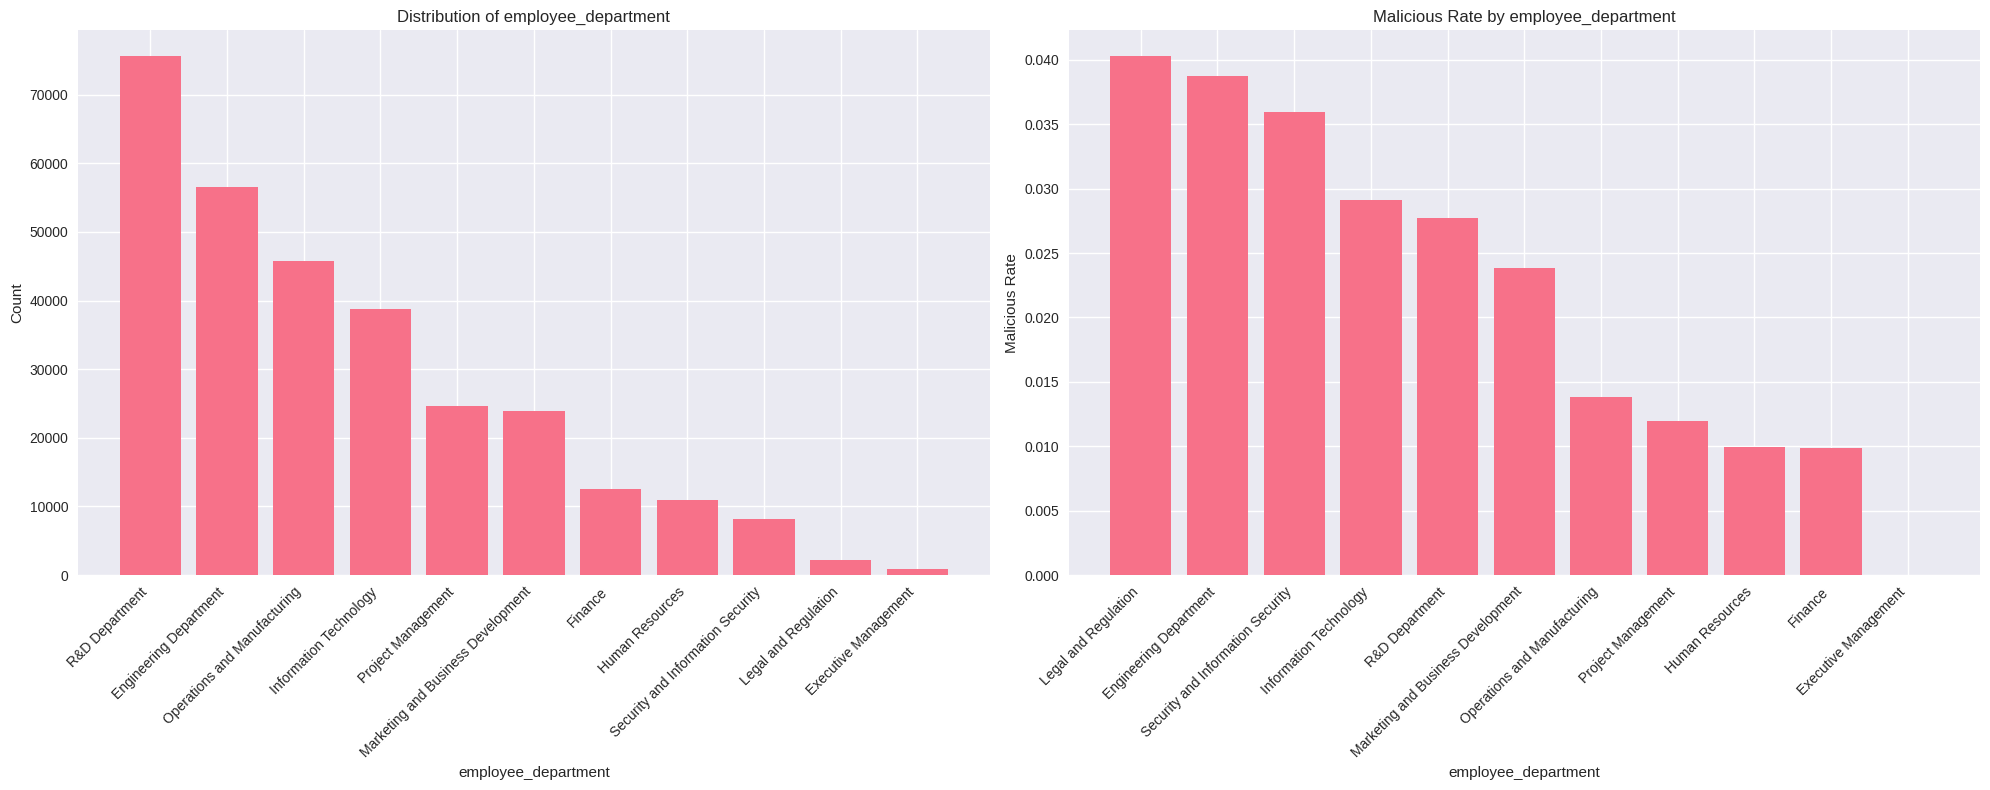

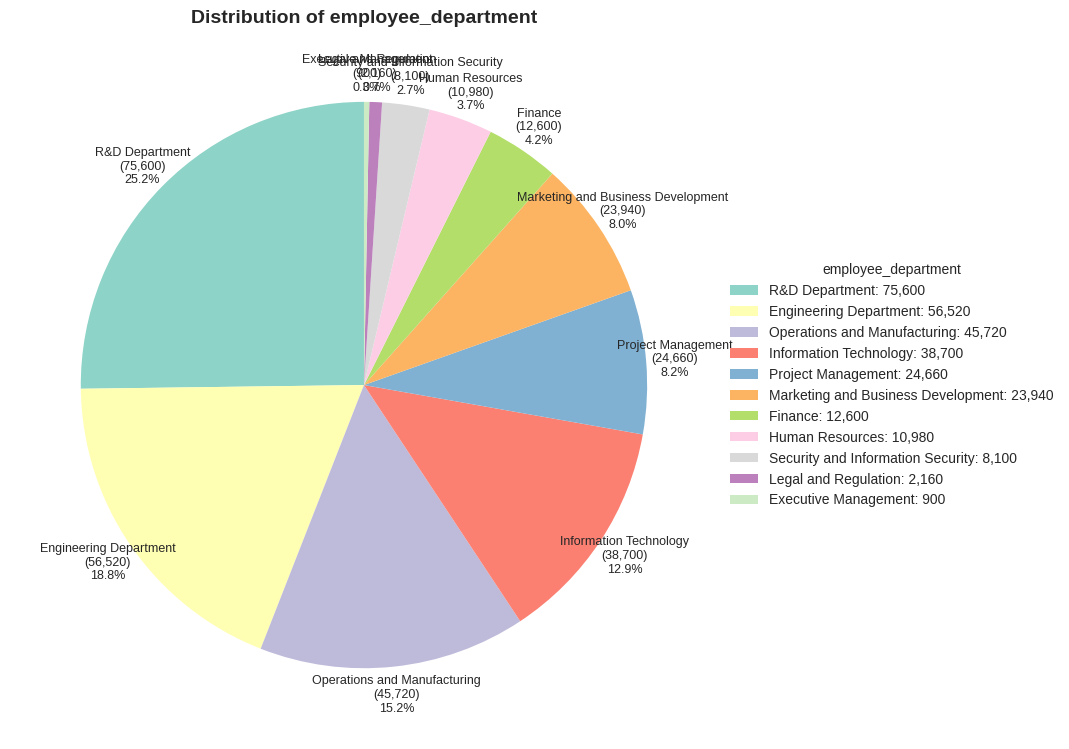

In [57]:
create_all_visualizations('employee_department', df, value_counts, malicious_rate)

**Clear risk hierarchy visible**: Charts confirm Legal and Engineering departments have highest malicious rates (~4%) despite different workforce sizes. Visual pattern shows inverse relationship - largest departments (R&D, Engineering) don't necessarily have lowest risk rates.

## Employee Position Analysis

In [58]:
value_counts = get_basic_categorical_stats('employee_position', df)


=== ANALYSIS OF EMPLOYEE_POSITION ===
Number of unique values: 48
Top 10 values:
employee_position
Secretary                                                  50040
Systems Engineer                                           22500
Integration and Testing Engineer                           15120
Development Engineer (Hardware / Software / Mechanical)    14940
Algorithm Engineer                                         11880
Process Engineer                                           10440
Head of R&D                                                10080
Design Engineer                                            10080
Test Engineer                                               9360
Head of Engineering                                         8820
Name: count, dtype: int64


**Secretary-heavy structure**: Secretaries comprise 17% of workforce (50K employees), followed by technical roles like Systems Engineers (7.5%) and Integration Engineers (5%). Large administrative layer suggests complex, hierarchical organization with significant support staff.

In [59]:
malicious_rate = calculate_malicious_rate('employee_position', df)


Malicious rate by employee_position:
                                 employee_position  total_count  \
13                                  Data Scientist         6120   
14               Defense Export Compliance Officer          540   
25               Information Security Investigator          900   
18  Enterprise Systems Developer (ERP / CRM / SAP)         5940   
27                Integration and Testing Engineer        15120   
22                             Head of Engineering         8820   
15                                 Design Engineer        10080   
33                         Physical Access Control         1620   
9        Chief Information Security Officer (CISO)         2520   
19                                 Finance Manager         1800   

    malicious_count  malicious_rate  
13              501        0.081863  
14               44        0.081481  
25               73        0.081111  
18              358        0.060269  
27              889        0.05879

**Data roles = highest risk**: Data Scientists (8.2%), Export Compliance Officers (8.1%), and Security Investigators (8.1%) show highest malicious rates - positions with sensitive data access pose greatest insider threat risk.

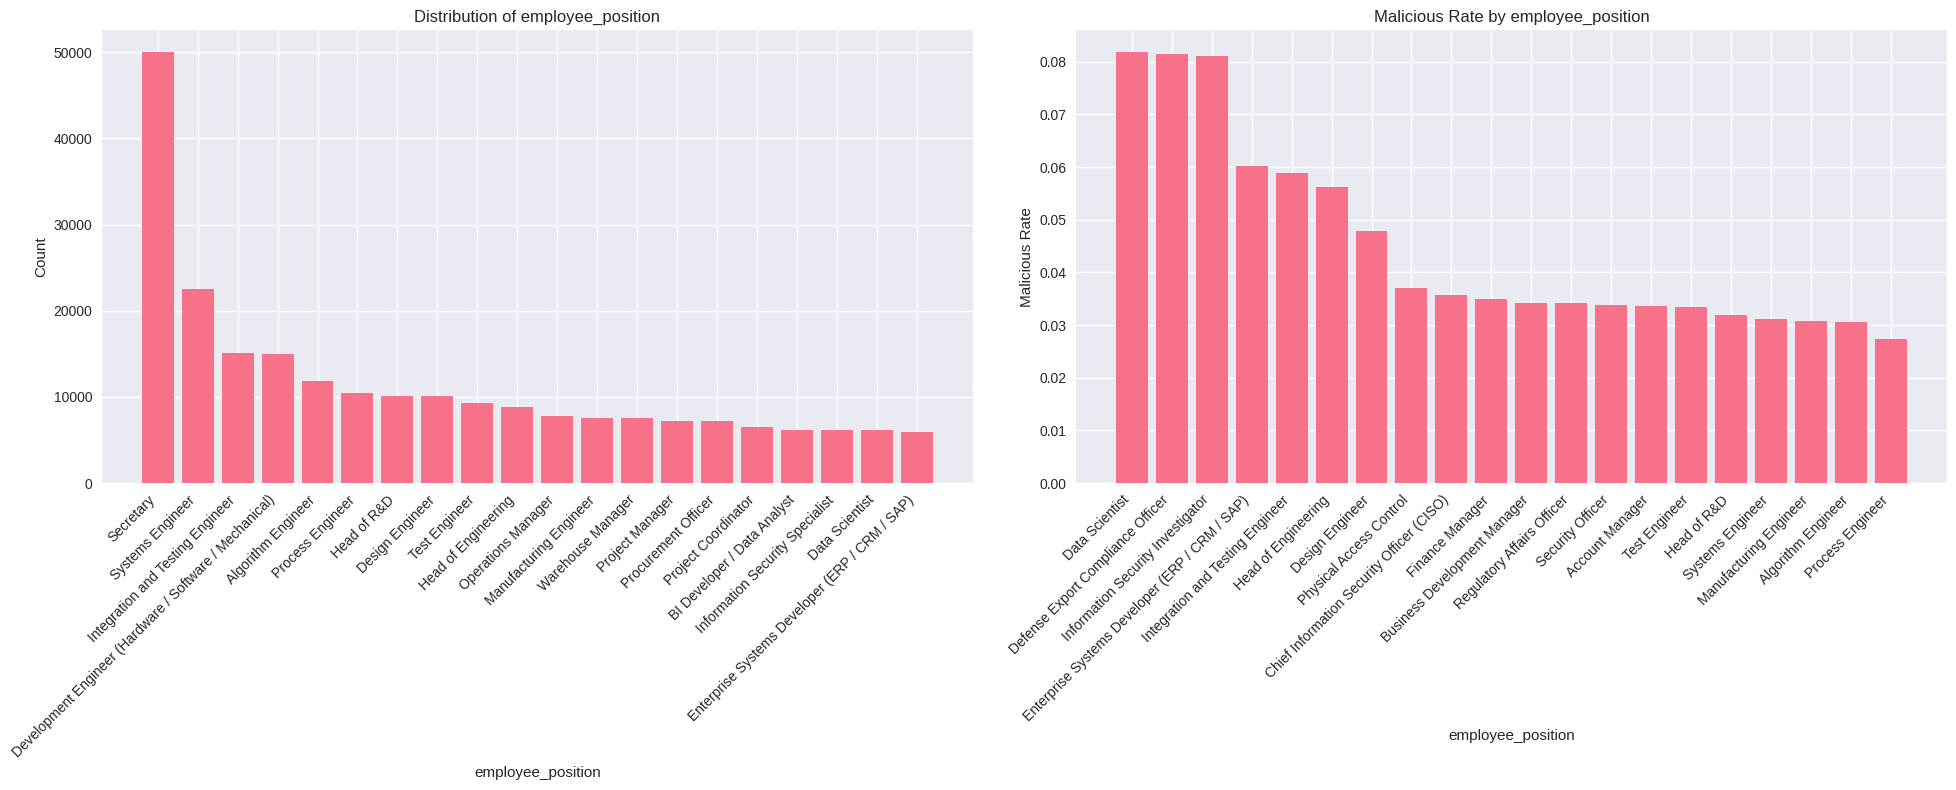

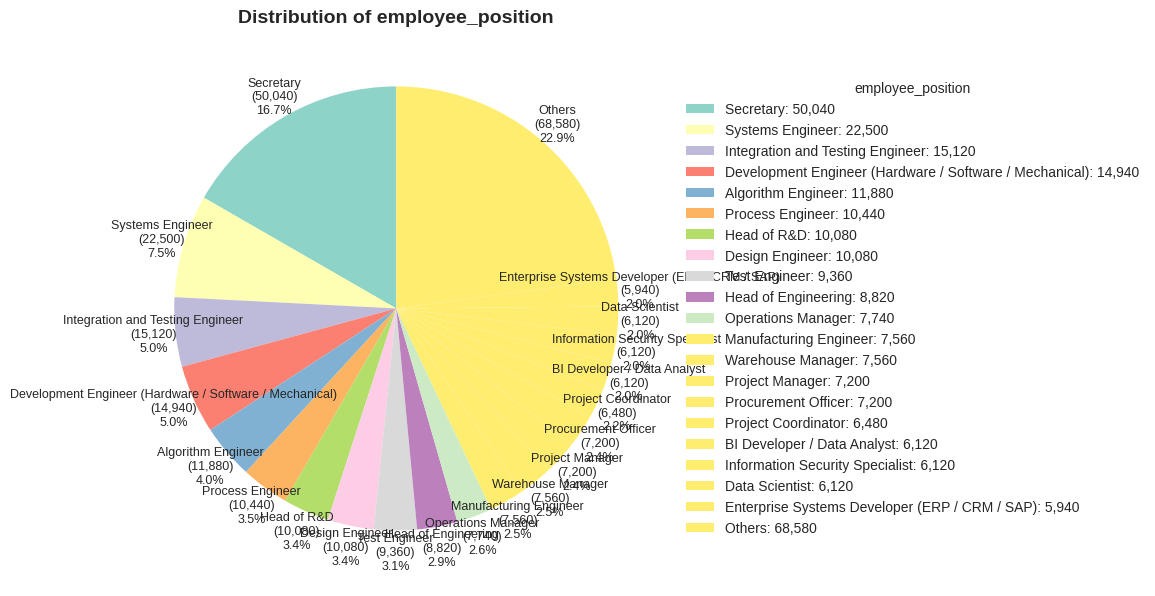

In [61]:
create_all_visualizations('employee_position', df, value_counts, malicious_rate)

**Clear risk stratification**: Charts show dramatic risk variation - Data Scientists, Compliance Officers, and Security Investigators have 8%+ malicious rates while most positions cluster around 3%. Secretary role dominates workforce but has moderate risk level.

## Employee Campus Analysis

In [62]:
value_counts = get_basic_categorical_stats('employee_campus', df)


=== ANALYSIS OF EMPLOYEE_CAMPUS ===
Number of unique values: 3
Top 10 values:
employee_campus
Campus A    101880
Campus C    100800
Campus B     97200
Name: count, dtype: int64


**Even tri-campus distribution**: Nearly equal workforce split across three campuses - Campus A (34%), Campus C (34%), Campus B (32%). Balanced distribution suggests coordinated multi-site operations.

In [63]:
malicious_rate = calculate_malicious_rate('employee_campus', df)


Malicious rate by employee_campus:
  employee_campus  total_count  malicious_count  malicious_rate
2        Campus C       100800             2724        0.027024
1        Campus B        97200             2596        0.026708
0        Campus A       101880             2201        0.021604


**Campus C highest risk**: Campus C (2.7%) and B (2.7%) show higher malicious rates than Campus A (2.2%) - location-based security differences may exist.

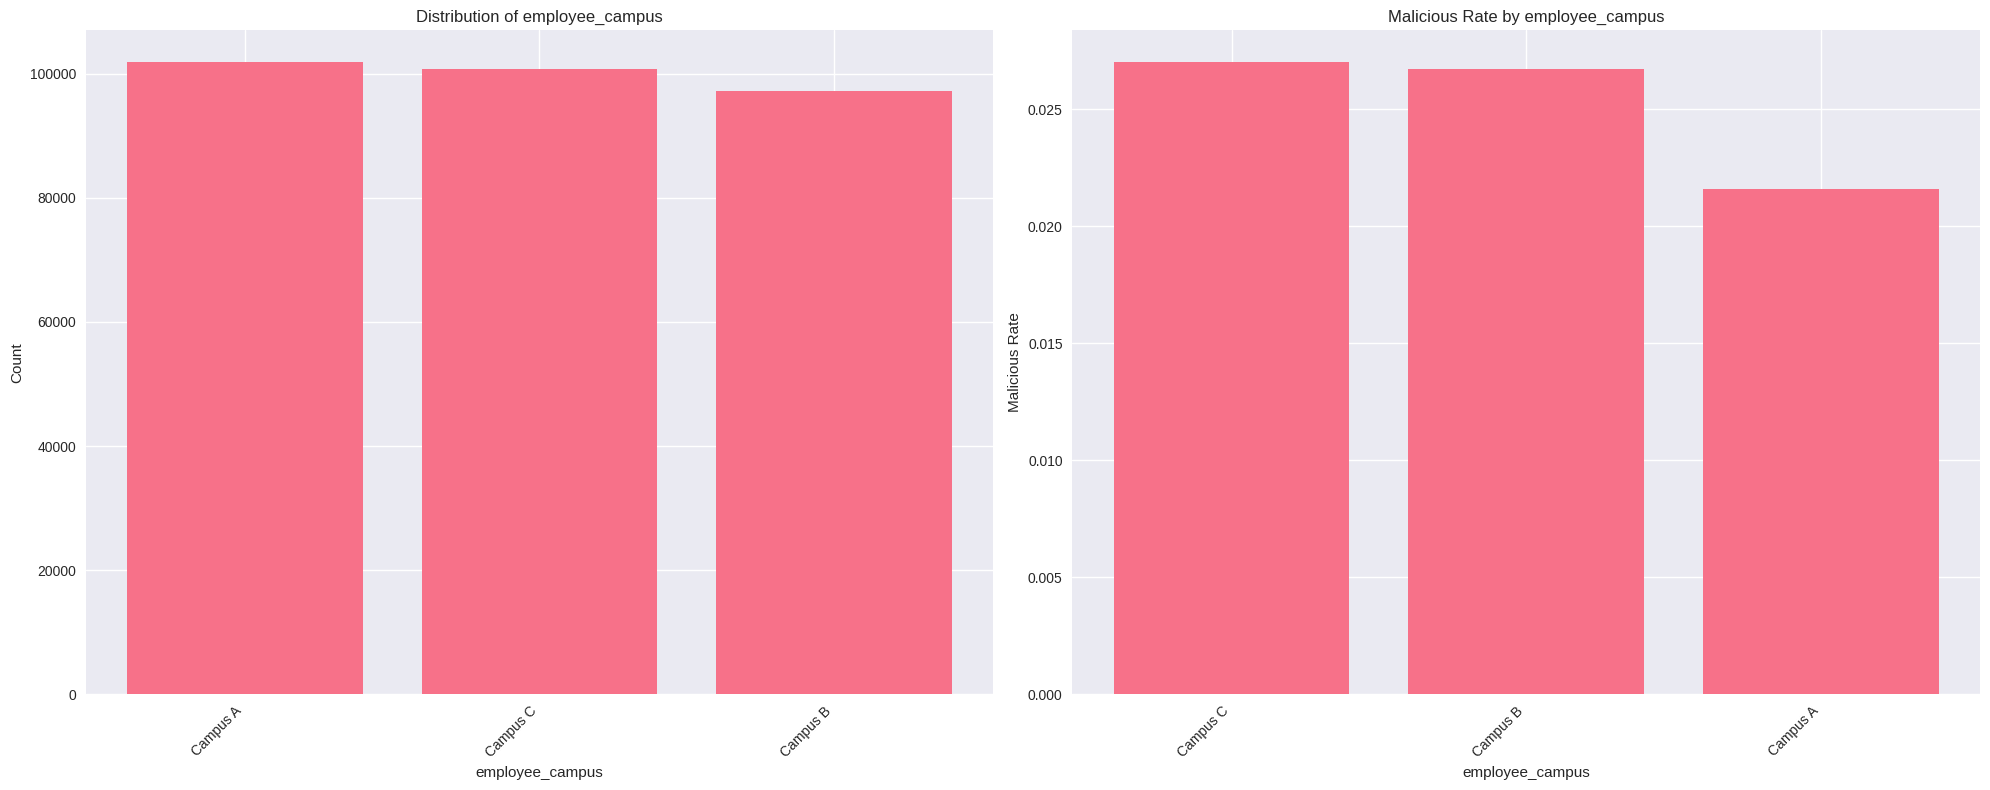

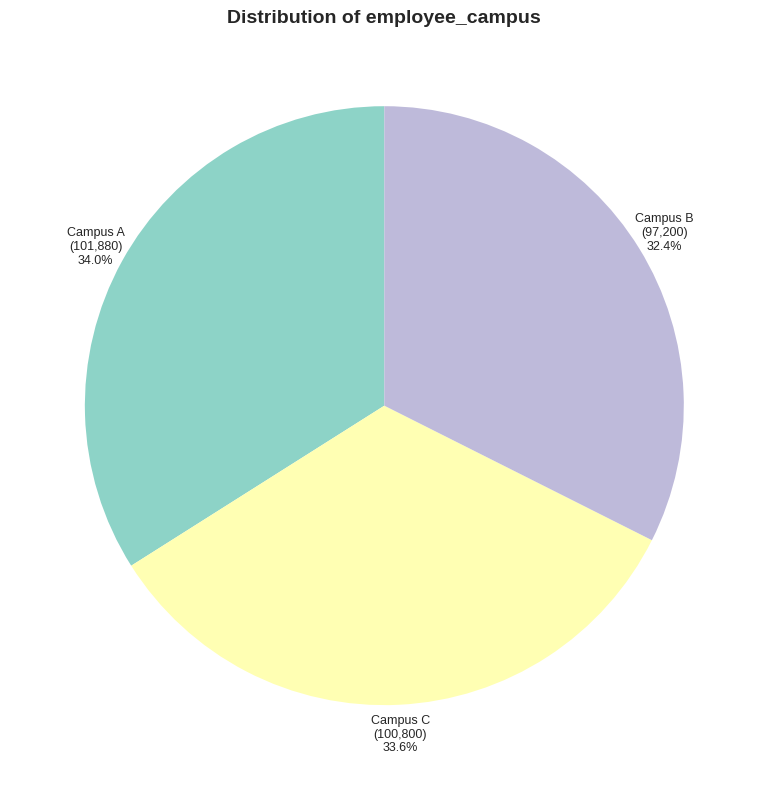

In [65]:
create_all_visualizations('employee_campus', df, value_counts, malicious_rate)

**Clear campus risk hierarchy**: Charts show Campus A is notably safer (2.2%) while Campus B and C have identical elevated risk (2.7%). The visual difference is small but statistically significant - suggests Campus A has better security controls.

## Employee Classifiacation Analysis

In [66]:
value_counts = get_basic_categorical_stats('employee_classification', df)


=== ANALYSIS OF EMPLOYEE_CLASSIFICATION ===
Number of unique values: 4
Top 10 values:
employee_classification
2    139860
1     84240
3     72720
4      3060
Name: count, dtype: int64


**Classification Level 2 dominates**: Level 2 (47%) is most common, followed by Level 1 (28%) and Level 3 (24%). Only 1% have highest Level 4 clearance - suggests pyramid security structure with most sensitive access highly restricted.

In [67]:
malicious_rate = calculate_malicious_rate('employee_classification', df)


Malicious rate by employee_classification:
   employee_classification  total_count  malicious_count  malicious_rate
3                        4         3060              205        0.066993
1                        2       139860             4132        0.029544
2                        3        72720             1711        0.023529
0                        1        84240             1473        0.017486


**Higher clearance = higher risk**: Counterintuitively, Level 4 (highest clearance) shows highest malicious rate (6.7%) vs Level 1 (1.7%). Pattern suggests insider threat increases with access level - trusted insiders pose greatest risk.

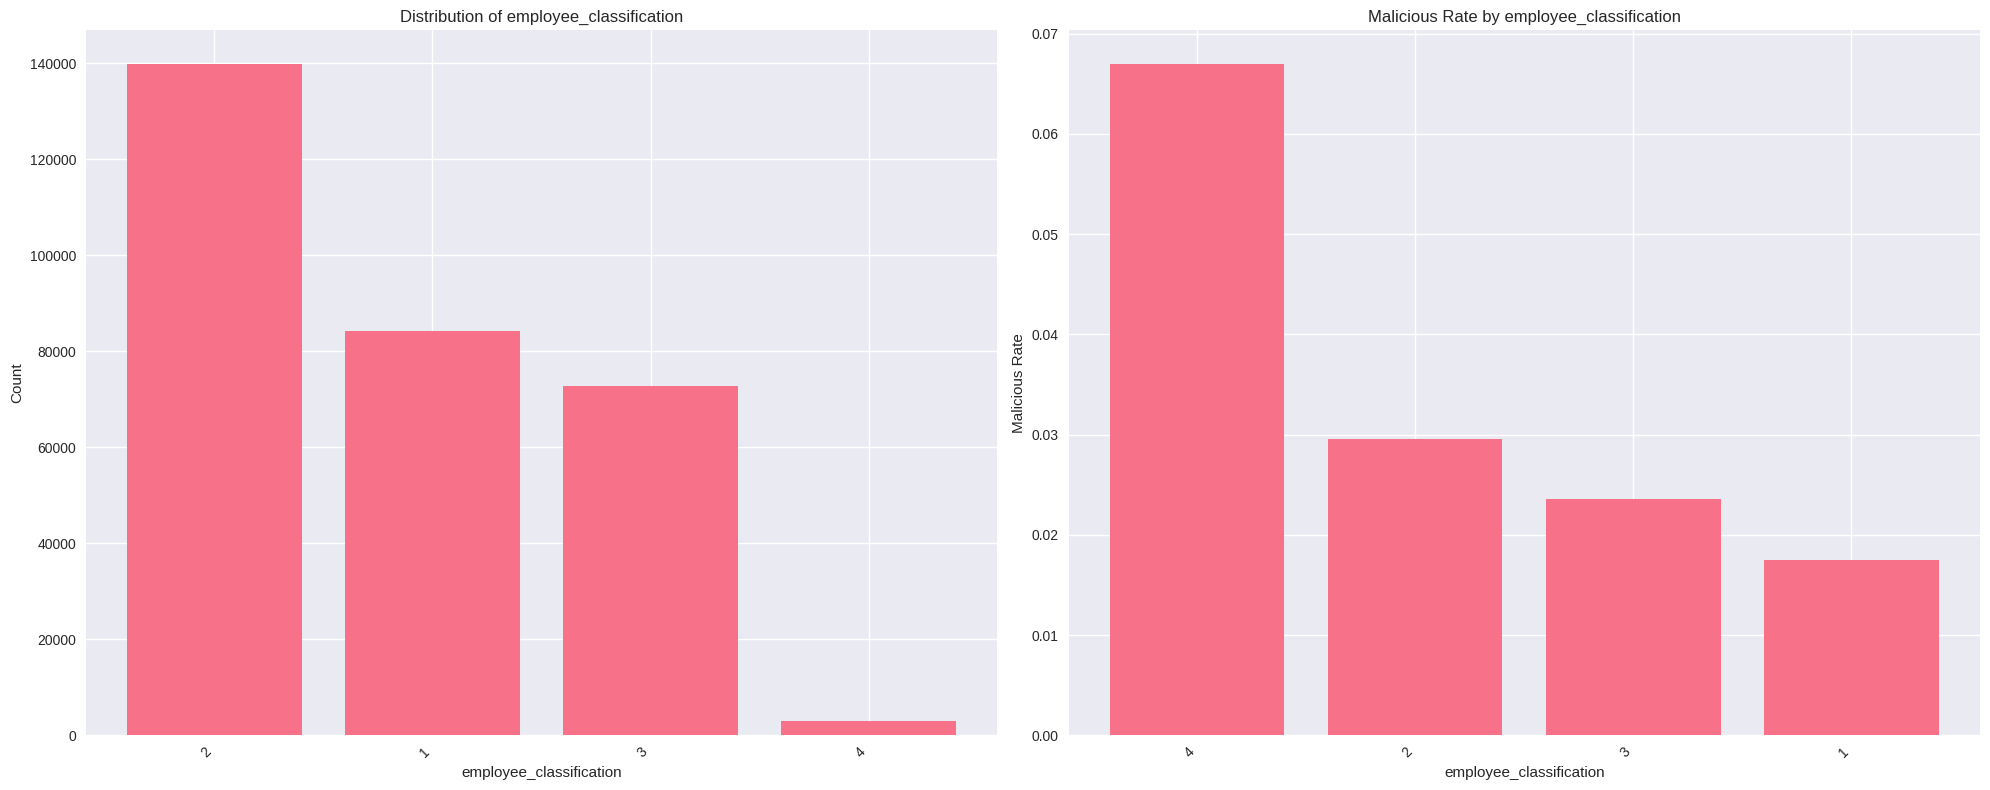

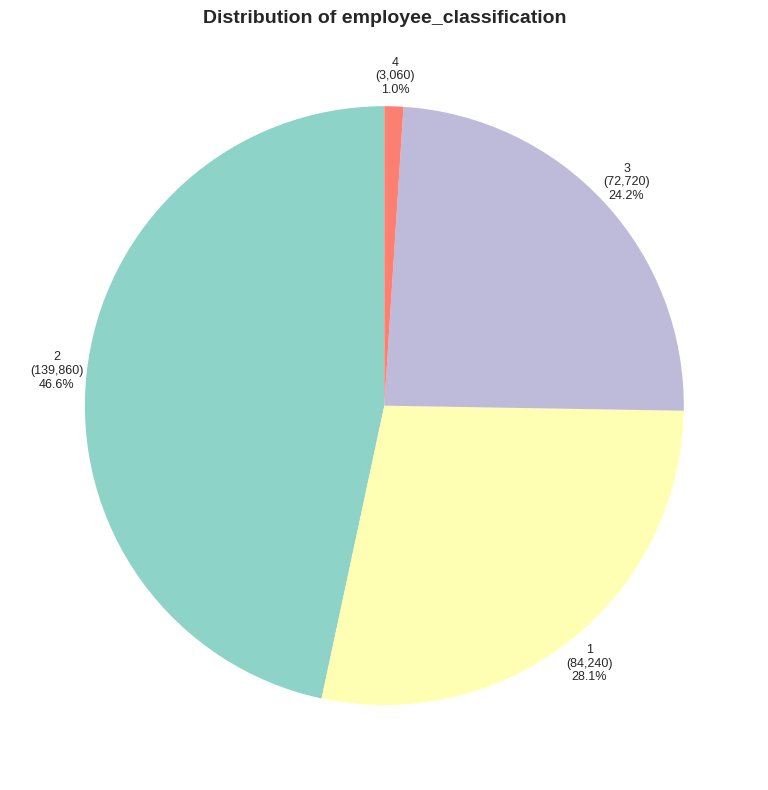

In [69]:
create_all_visualizations('employee_classification', df, value_counts, malicious_rate)

**Dramatic inverse relationship**: Charts clearly show higher clearance = higher risk - Level 4 has nearly 4x the malicious rate of Level 1 (6.7% vs 1.7%). Classic insider threat paradox: most trusted employees pose greatest security risk.

## Origin Country Analysis

In [70]:
value_counts = get_basic_categorical_stats('employee_origin_country', df)


=== ANALYSIS OF EMPLOYEE_ORIGIN_COUNTRY ===
Number of unique values: 32
Top 10 values:
employee_origin_country
Israel       126360
Russia        25200
Ukraine       21240
France        17280
Ethiopia      14400
USA           14400
Morocco        9000
Argentina      7200
UK             7200
India          6120
Name: count, dtype: int64


**Israeli-majority workforce**: Israel dominates (42%) followed by Russia (8.4%), Ukraine (7.1%), and France (5.8%). Highly international workforce with 32 countries represented - suggests global organization based in Israel with significant Eastern European talent acquisition.

In [71]:
malicious_rate = calculate_malicious_rate('employee_origin_country', df)


Malicious rate by employee_origin_country:
   employee_origin_country  total_count  malicious_count  malicious_rate
3                    China         4500              576        0.128000
19                  Poland         2700              234        0.086667
31                   Yemen         1080               88        0.081481
10                    Iran         1440               98        0.068056
1                   Brazil         3780              206        0.054497
2                   Canada         5040              258        0.051190
9                    India         6120              276        0.045098
4                 Ethiopia        14400              431        0.029931
12                  Israel       126360             3248        0.025704
5                   France        17280              436        0.025231


**China shows highest risk**: China leads malicious activity (12.8%) followed by Poland (8.7%) and Yemen (8.1%). Israeli employees show moderate risk (2.6%) - suggests geopolitical considerations in security monitoring.

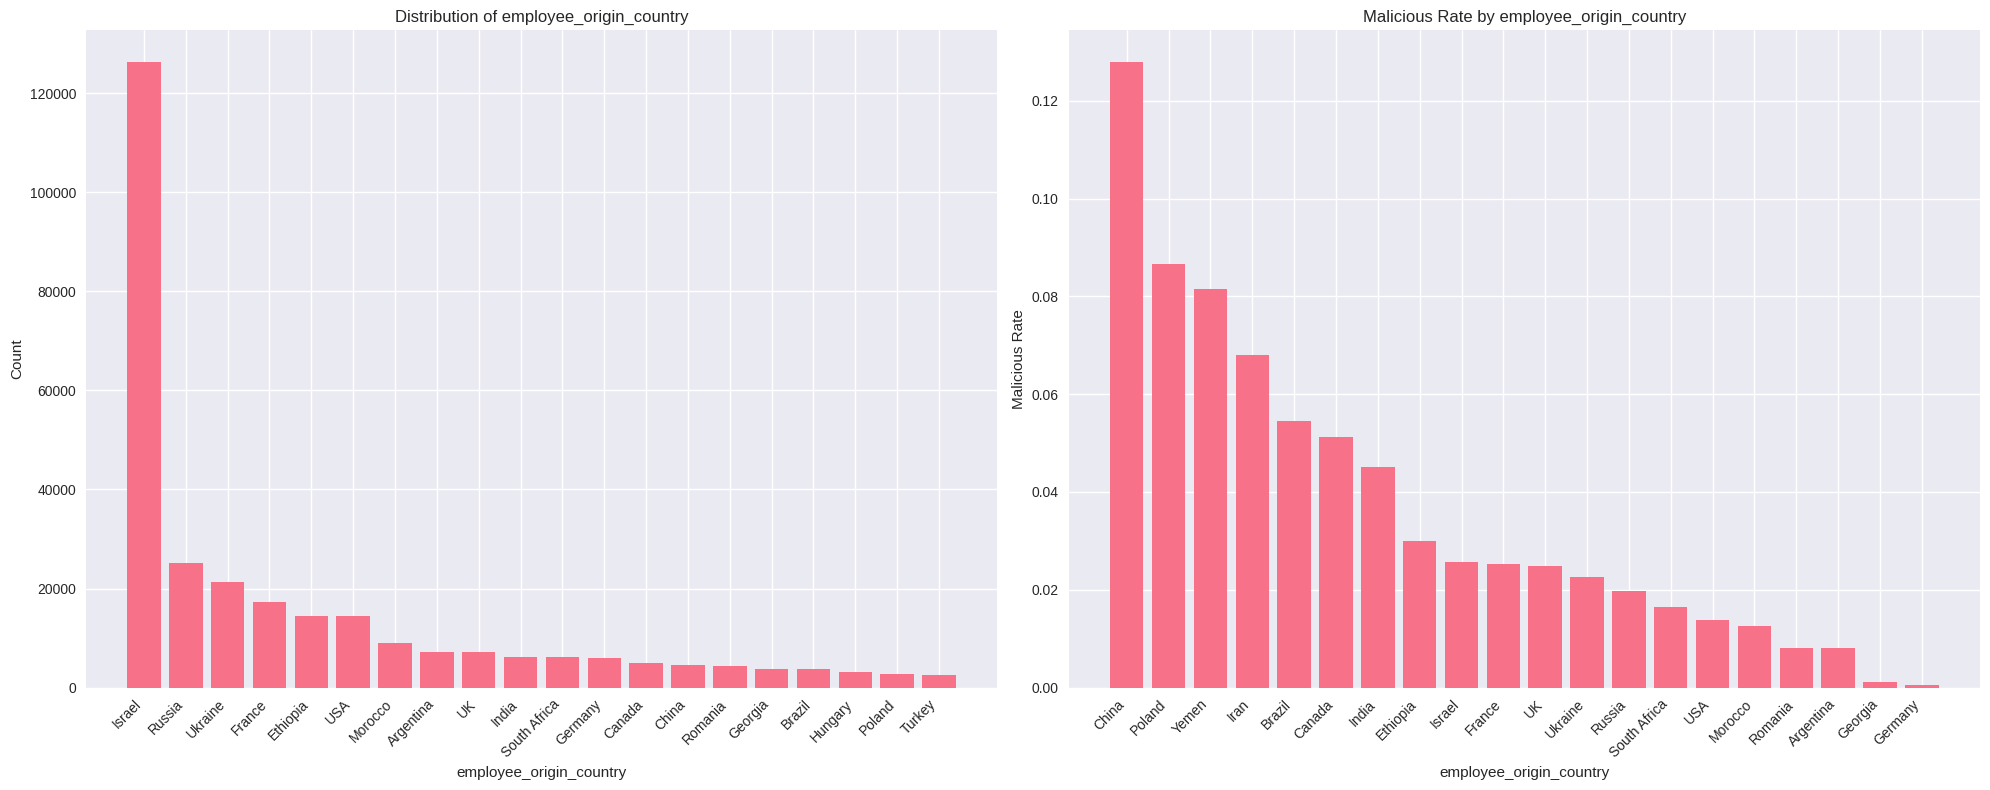

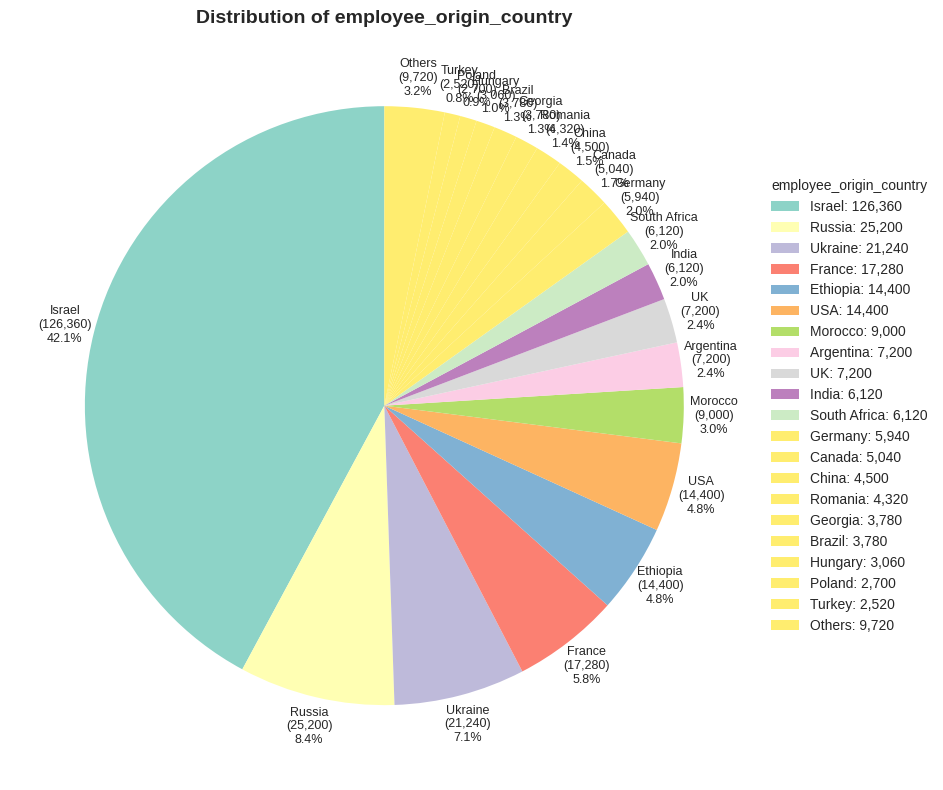

In [73]:
create_all_visualizations('employee_origin_country', df, value_counts, malicious_rate)

**Stark risk variation by origin**: Charts show dramatic 13x difference between highest (China 12.8%) and lowest risk countries. Israel's large workforce has moderate risk (2.6%), while smaller cohorts from certain countries show extreme rates - suggests country-specific security protocols needed.

## Trip Country Analysis

In [74]:
value_counts = get_basic_categorical_stats('country_name', df)


=== ANALYSIS OF COUNTRY_NAME ===
Number of unique values: 38
Top 10 values:
country_name
Turkey     742
Greece     657
USA        652
Cyprus     491
Italy      458
UK         413
Germany    340
UAE        330
France     302
Spain      235
Name: count, dtype: int64


**Regional travel focus**: Among 6K international trips, Turkey (12%) leads destinations, followed by Greece (11%) and USA (11%). Strong Mediterranean/European focus with UAE as key Middle East destination - suggests business operations concentrated in these regions.

In [75]:
malicious_rate = calculate_malicious_rate('country_name', df)


Malicious rate by country_name:
   country_name  total_count  malicious_count  malicious_rate
21     Pakistan            9                9        1.000000
11         Iran           24               24        1.000000
22        Qatar           16               16        1.000000
29        Syria           31               27        0.870968
16      Lebanon           18               14        0.777778
24       Russia           17               13        0.764706
37        Yemen           21               16        0.761905
36      Ukraine           51               38        0.745098
28  Switzerland           26               13        0.500000
31      Tunisia           43               18        0.418605


**Extreme travel-based risk**: Certain countries show 100% malicious rates (Pakistan, Iran, Qatar) while others approach it (Syria 87%, Lebanon 78%). Travel destination is a critical security indicator - some locations require immediate flagging.

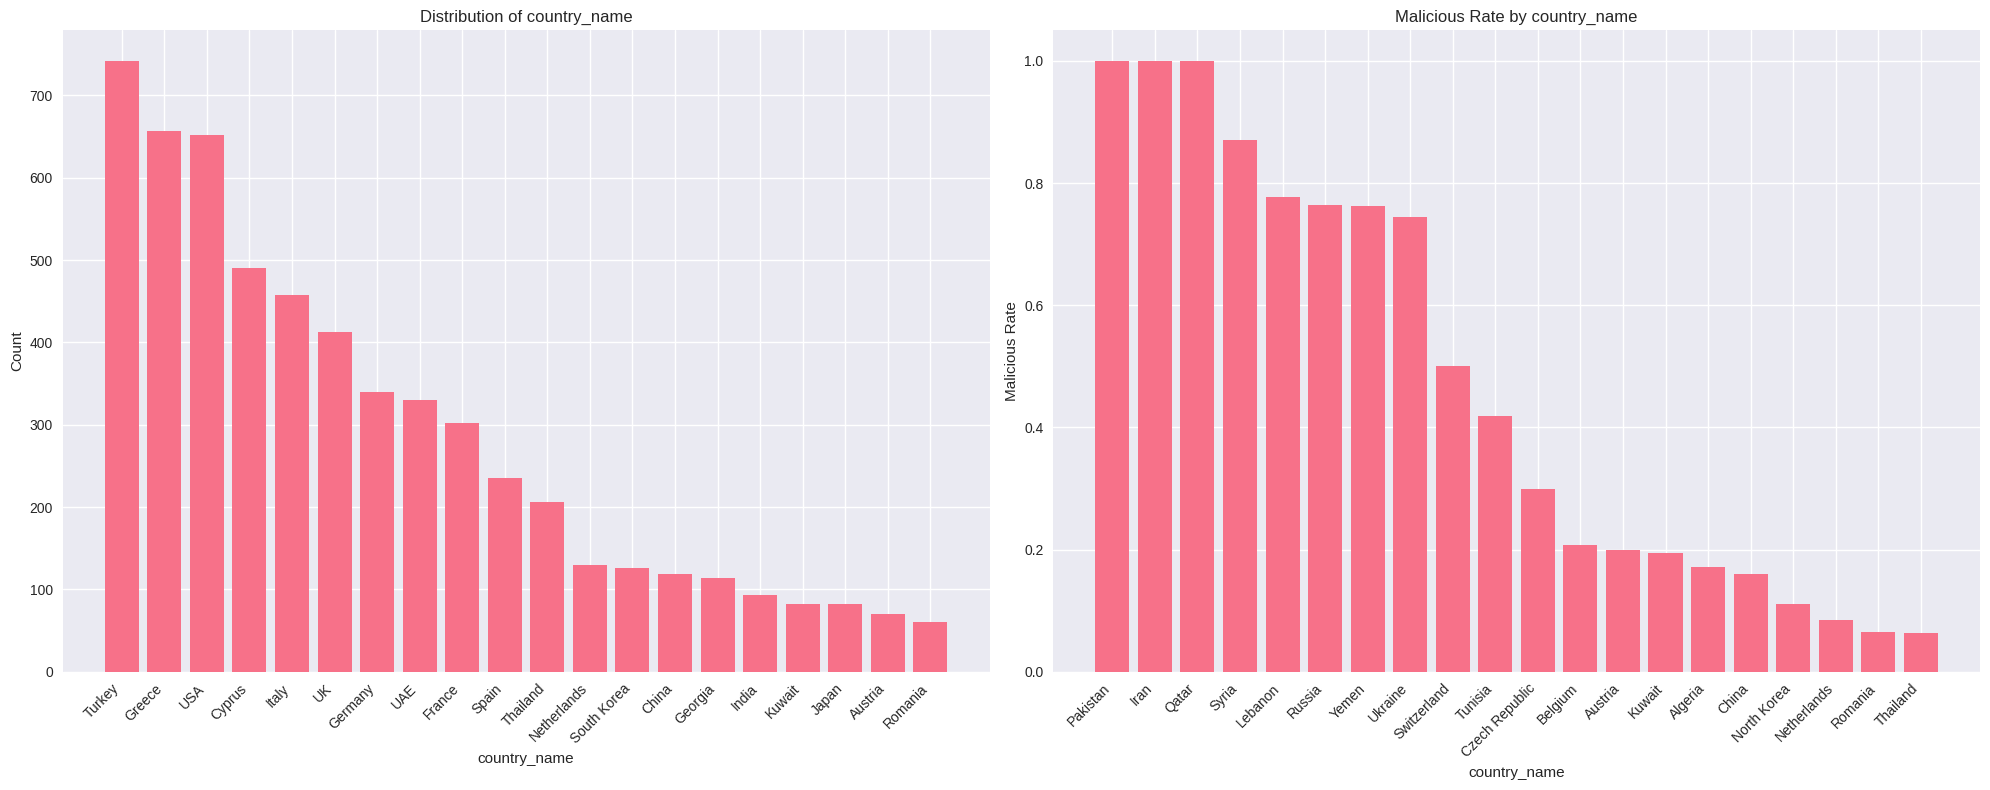

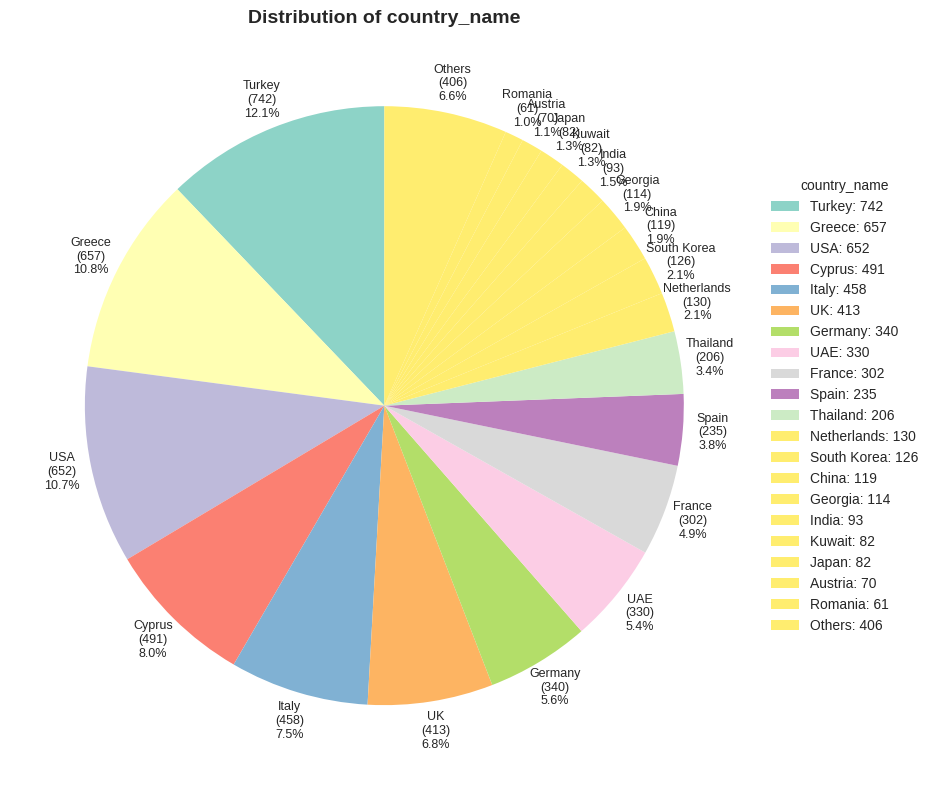

In [77]:
create_all_visualizations('country_name', df, value_counts, malicious_rate)

**Complete geographic risk stratification**: Charts reveal perfect inverse relationship - most popular destinations (Turkey, Greece, USA) have low malicious rates (~5-20%) while less frequented countries show extreme rates (Pakistan/Iran/Qatar at 100%). Travel volume inversely correlates with security risk.